# **Taller 3 - Clustering para reconciliación de fotos**

Presentado por: Andrea Correa Magaña, Paula Estefania Guarin Tangarife, Juan Sebastian Calderon Guevara

## Importación librerías

In [1]:
#Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_olivetti_faces
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    confusion_matrix
)
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans

#Paleta colores
AZUL_OSCURO = "#0D47A1"
AZUL = "#1E88E5"
AZUL_CLARO = "#90CAF9"
AZUL_SUAVE = "#E3F2FD"

PALETA_AZUL = [
    "#0D47A1",
    "#1565C0",
    "#1E88E5",
    "#42A5F5",
    "#64B5F6",
    "#90CAF9",
    "#BBDEFB"
]

#Estilo de las gráficas
sns.set_style("white")

plt.rcParams.update({
    "axes.prop_cycle": plt.cycler(color=PALETA_AZUL),
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": AZUL_SUAVE,
    "grid.linewidth": 0.8,
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.labelsize": 12
})

def mostrar_tabla(df, titulo, cols_pct=None):
    """Muestra una tabla con formato profesional en tonos azules."""

    cols_pct = cols_pct or []
    df_fmt = df.copy()

    for col in df_fmt.columns:
        if col in cols_pct:
            df_fmt[col] = df_fmt[col].apply(lambda x: f"{x:.1%}")
        elif pd.api.types.is_float_dtype(df_fmt[col]):
            df_fmt[col] = df_fmt[col].apply(lambda x: f"{x:.4f}")

    ancho = min(2 + 1.6 * len(df_fmt.columns), 12)
    alto = 0.8 + 0.5 * len(df_fmt)

    fig, ax = plt.subplots(figsize=(ancho, alto))
    ax.axis("off")

    tabla = ax.table(
        cellText=df_fmt.values,
        colLabels=df_fmt.columns,
        cellLoc="center",
        loc="center"
    )

    tabla.auto_set_font_size(False)
    tabla.set_fontsize(11)
    tabla.scale(1, 2)

    for (fila, col), celda in tabla.get_celld().items():

        celda.set_edgecolor("white")
        celda.set_linewidth(2)

        if fila == 0:
            celda.set_facecolor(AZUL_OSCURO)
            celda.get_text().set_color("white")
            celda.get_text().set_fontweight("bold")

        else:
            if fila % 2 == 0:
                celda.set_facecolor(AZUL_SUAVE)
            else:
                celda.set_facecolor("white")

    plt.title(titulo, fontsize=14, fontweight="bold", pad=18)

    plt.tight_layout()
    plt.show()

## Paso 1. Exploración de los datos

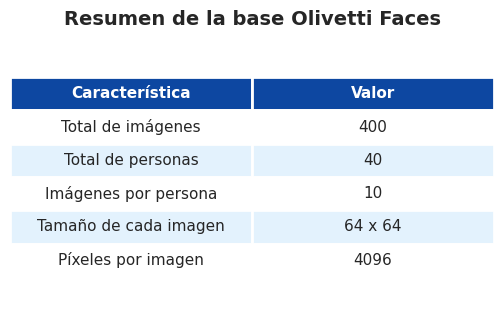

In [2]:
#Cargar datos
datos = fetch_olivetti_faces()

#Variables principales
X = datos.data
imagenes = datos.images
personas = datos.target

#Cantidades
total_imagenes = len(imagenes)
total_personas = len(np.unique(personas))
alto = imagenes.shape[1]
ancho = imagenes.shape[2]
pixeles = X.shape[1]

# Número de fotos por persona
fotos_persona = total_imagenes / total_personas

#Tabla
resumen = pd.DataFrame({
    "Característica": [
        "Total de imágenes",
        "Total de personas",
        "Imágenes por persona",
        "Tamaño de cada imagen",
        "Píxeles por imagen"
    ],
    "Valor": [
        total_imagenes,
        total_personas,
        int(fotos_persona),
        f"{alto} x {ancho}",
        pixeles
    ]
})

mostrar_tabla(resumen, "Resumen de la base Olivetti Faces")

In [3]:
#Número fotografías por persona
cantidad_persona = pd.Series(personas).value_counts().sort_index()

cantidad_persona

,count
0,10
1,10
2,10
3,10
4,10
5,10
6,10
7,10
8,10
9,10


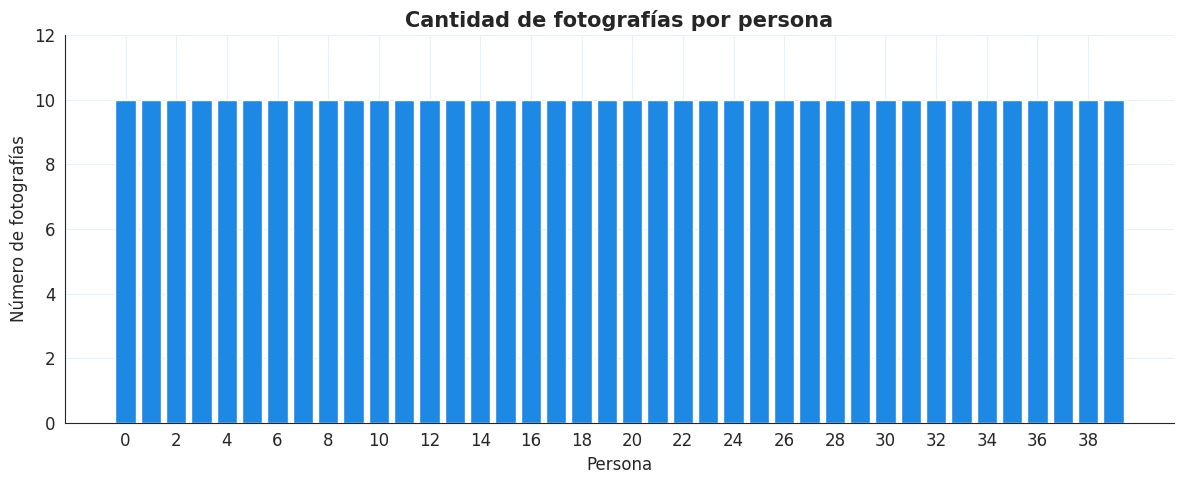

In [4]:
# Gráfica de fotografías por persona
plt.figure(figsize=(12, 5))

plt.bar(
    cantidad_persona.index,
    cantidad_persona.values,
    color=AZUL
)

plt.title("Cantidad de fotografías por persona")
plt.xlabel("Persona")
plt.ylabel("Número de fotografías")

plt.xticks(range(0, 40, 2))
plt.ylim(0, 12)

plt.tight_layout()
plt.show()

De acuerdo con el análisis descriptivo de la base de datos, podemos identificar que contiene **400 fotografías** correspondientes a **40 personas**, las cuales tienen exactamente **10 imágenes** almacenadas *(ninguna persona esta sobrerrepresentada)*. Cada imagen tiene una dimensión de 64 × 64 píxeles, equivalente a 4.096 características; esto significa una cantidad relativamente alta de dimensiones.

En esta base de prueba, las identidades están perfectamente balanceadas, esto puede variar en el archivo de producción de empleados, ya que puede haber personas con una sola fotografía o imagénes repetidas, por lo tanto hay que tener precaución al replicarlo en producción.

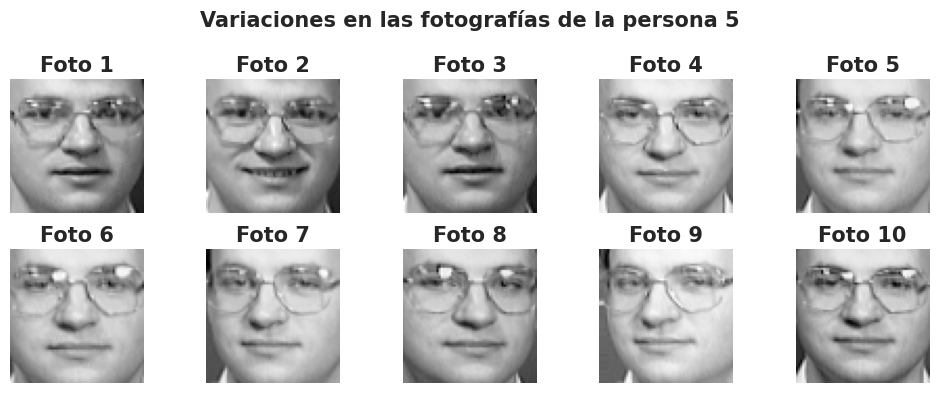

In [5]:
#Persona seleccionada
persona = 5

#Buscar sus fotografías
posiciones = np.where(personas == persona)[0]

#Crear la figura
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flat):

    pos = posiciones[i]

    ax.imshow(
        imagenes[pos],
        cmap="gray"
    )

    ax.set_title(f"Foto {i + 1}")
    ax.axis("off")

plt.suptitle(
    f"Variaciones en las fotografías de la persona {persona}",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

Al seleccionar y observar las diez fotografías correspondientes, se pueden identificar variaciones en aspectos como iluminación, expresión facial, posición del rostro y el porte de gafas.

Para una sola persona, estas diferencias no modifican su identidad. Sin embargo, para un algoritmo que compara fotografías, esto podría presentar un problema, ya que se puede dar demasiado peso a la iluminación o a pequeños cambios de pose y separar imágenes de una misma persona en diferentes clusters.

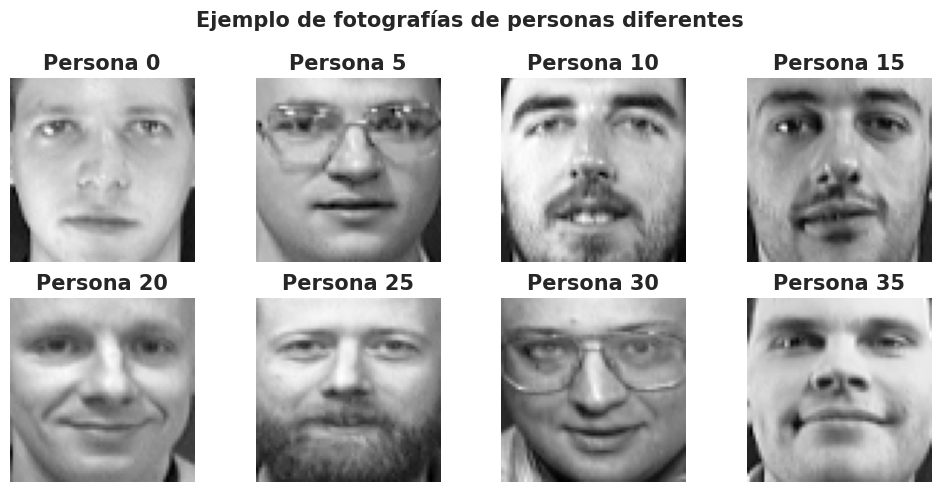

In [6]:
# Diferentes personas para comparar
personas_muestra = [0, 5, 10, 15, 20, 25, 30, 35]

fig, axes = plt.subplots(2, 4, figsize=(10, 5))

for i, ax in enumerate(axes.flat):

    persona = personas_muestra[i]

    # Primera fotografía de cada persona
    pos = np.where(personas == persona)[0][0]

    ax.imshow(
        imagenes[pos],
        cmap="gray"
    )

    ax.set_title(f"Persona {persona}")
    ax.axis("off")

plt.suptitle(
    "Ejemplo de fotografías de personas diferentes",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

La comparación entre personas diferentes muestra que existen características faciales que permiten distinguir visualmente las identidades; pero también pueden presentarse similitudes entre algunos individuos, especialmente cuando las fotografías tienen iluminación, posición o expresión similares. Basado en esto el algoritmo debe aprender una estructura en la que las diez fotografías de una persona sean suficientemente similares entre sí y al mismo tiempo, diferentes de las fotografías de las otras 39 personas de la base.

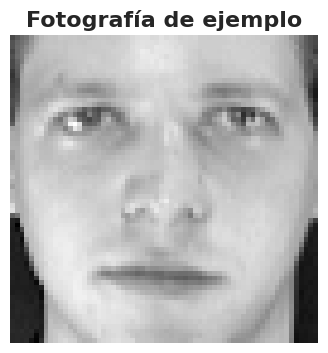

In [7]:
# Seleccionar una fotografía de ejemplo
posicion = 0

imagen = datos.images[posicion]

# Mostrar la fotografía original
plt.figure(figsize=(4, 4))

plt.imshow(imagen, cmap="gray")
plt.axis("off")
plt.title("Fotografía de ejemplo", fontsize=16, fontweight="bold")

plt.show()

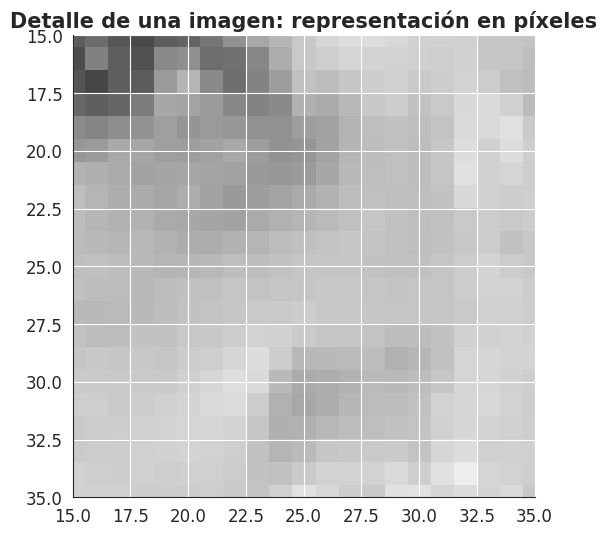

In [8]:
# Mostrar una zona ampliada para observar los píxeles
plt.figure(figsize=(6, 6))

plt.imshow(imagen, cmap="gray")

plt.xlim(15, 35)
plt.ylim(35, 15)

plt.grid(True, color="white", linewidth=0.8)

plt.title(
    "Detalle de una imagen: representación en píxeles",
    fontsize=15,
    fontweight="bold"
)

plt.show()

Cada fotografía está formada por una matriz de 64 × 64 píxeles, lo que representa 4.096 valores por imagen. Aunque visualmente observamos un rostro, para el análisis cada fotografía está compuesta por información numérica que puede ser utilizada posteriormente para medir similitudes entre imágenes.

## Paso 2. Preparación de los datos

In [9]:
# Imágenes originales
imagenes = datos.images

# Vectorizar las imágenes
X_crudo = imagenes.reshape(
    imagenes.shape[0],
    -1
)

# Mostrar dimensiones
print("Dimensión original:", imagenes.shape)
print("Dimensión vectorizada:", X_crudo.shape)

Dimensión original: (400, 64, 64)
Dimensión vectorizada: (400, 4096)


Filas: 400
Columnas: 4096


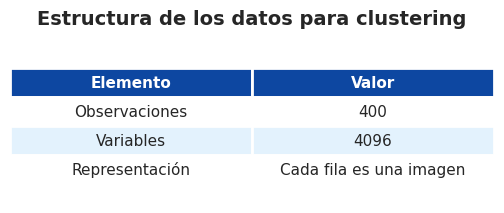

In [10]:
# Dimensión de la matriz
print("Filas:", X_crudo.shape[0])
print("Columnas:", X_crudo.shape[1])

# Resumen de la estructura de los datos
preparacion = pd.DataFrame({
    "Elemento": [
        "Observaciones",
        "Variables",
        "Representación"
    ],
    "Valor": [
        X_crudo.shape[0],
        X_crudo.shape[1],
        "Cada fila es una imagen"
    ]
})

mostrar_tabla(
    preparacion,
    "Estructura de los datos para clustering"
)

Las imágenes originales tienen una dimensión de 64 × 64 píxeles. Para poder utilizar modelos de clustering, cada imagen fue transformada en un vector de valores numéricos; como resultado, cada fotografía pasó de tener una estructura de 64 × 64 a un vector de 4.096 píxeles.

La matriz final utilizada para el análisis tiene una dimensión de 400 filas y 4.096 columnas. Cada fila representa una fotografía y cada columna representa la intensidad de un píxel.

Mínimo: 0.0
Máximo: 1.0
Promedio: 0.5470426
Desviación estándar: 0.17251527


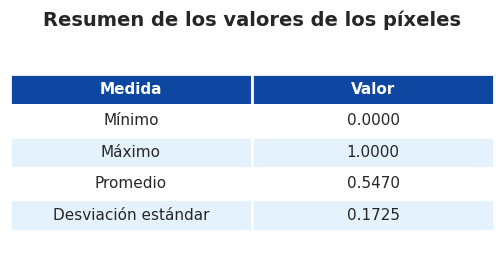

In [11]:
# Revisar los valores de los píxeles
print("Mínimo:", X_crudo.min())
print("Máximo:", X_crudo.max())
print("Promedio:", X_crudo.mean())
print("Desviación estándar:", X_crudo.std())

# Resumen de la escala de los píxeles
escala = pd.DataFrame({
    "Medida": [
        "Mínimo",
        "Máximo",
        "Promedio",
        "Desviación estándar"
    ],
    "Valor": [
        X_crudo.min(),
        X_crudo.max(),
        X_crudo.mean(),
        X_crudo.std()
    ]
})

mostrar_tabla(
    escala,
    "Resumen de los valores de los píxeles"
)

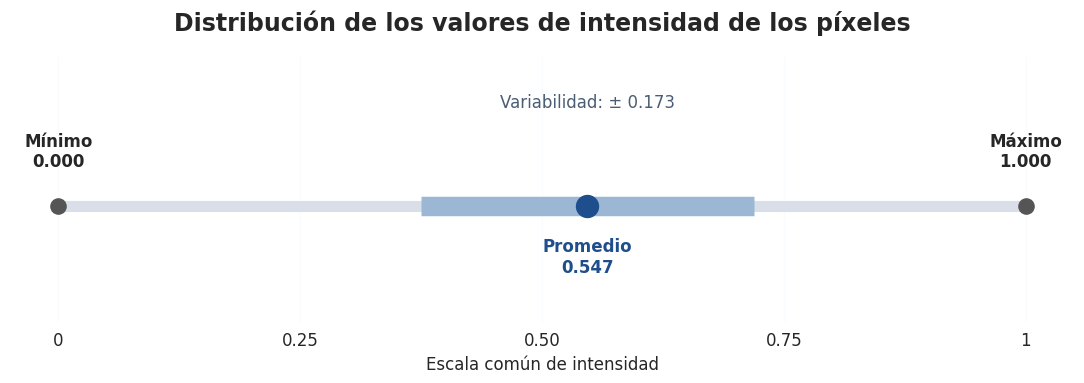

In [12]:
# Valores obtenidos en el análisis
minimo = 0.0000
maximo = 1.0000
promedio = 0.5470
desviacion = 0.1725

# Crear figura
plt.figure(figsize=(11, 4))

# Línea principal de la escala
plt.hlines(
    y=0,
    xmin=minimo,
    xmax=maximo,
    linewidth=8,
    color="#D9DEE8"
)

# Rango de una desviación estándar
limite_inferior = promedio - desviacion
limite_superior = promedio + desviacion

plt.hlines(
    y=0,
    xmin=limite_inferior,
    xmax=limite_superior,
    linewidth=14,
    color="#9BB7D4",
    label="± 1 desviación estándar"
)

# Punto del promedio
plt.scatter(
    promedio,
    0,
    s=250,
    color="#1F4E8C",
    zorder=3
)

# Marcar mínimo y máximo
plt.scatter(
    [minimo, maximo],
    [0, 0],
    s=120,
    color="#555555",
    zorder=3
)

# Etiquetas
plt.text(
    minimo,
    0.12,
    "Mínimo\n0.000",
    ha="center",
    fontsize=12,
    fontweight="bold"
)

plt.text(
    maximo,
    0.12,
    "Máximo\n1.000",
    ha="center",
    fontsize=12,
    fontweight="bold"
)

plt.text(
    promedio,
    -0.20,
    "Promedio\n0.547",
    ha="center",
    fontsize=12,
    fontweight="bold",
    color="#1F4E8C"
)

# Texto de desviación
plt.text(
    promedio,
    0.30,
    "Variabilidad: ± 0.173",
    ha="center",
    fontsize=12,
    color="#4A5D73"
)

# Formato
plt.xlim(-0.05, 1.05)
plt.ylim(-0.35, 0.45)

plt.xticks(
    [0, 0.25, 0.50, 0.75, 1.00],
    ["0", "0.25", "0.50", "0.75", "1"]
)

plt.yticks([])

plt.title(
    "Distribución de los valores de intensidad de los píxeles",
    fontsize=17,
    fontweight="bold",
    pad=20
)

plt.xlabel("Escala común de intensidad", fontsize=12)

plt.grid(axis="x", alpha=0.2)

plt.box(False)

plt.tight_layout()
plt.show()

Se decidió no aplicar una estandarización ya que los valores de los píxeles se encuentran entre 0 y 1 y todas las 4.096 variables representan la misma unidad de medida: la intensidad de un píxel. Por tanto, los datos ya se encuentran en una escala común.

Además, estandarizar cada píxel de manera independiente modificaría su distribución según la variabilidad observada en cada posición de las imágenes. Esto cambiaría la representación original de los rostros.

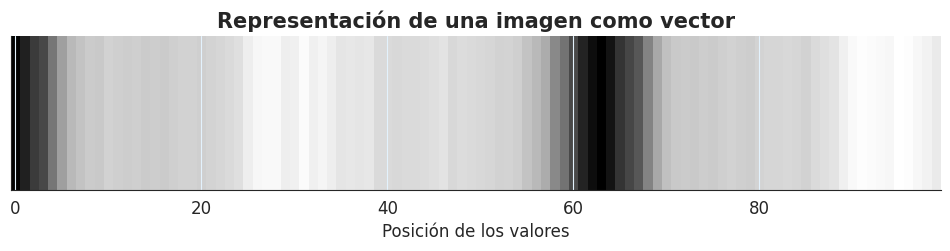

In [13]:
#Representación de un vector
plt.figure(figsize=(12, 2))
vector = X_crudo[0]

plt.imshow(
    vector[:100].reshape(1, -1),
    cmap="gray",
    aspect="auto"
)

plt.yticks([])
plt.title(
    "Representación de una imagen como vector",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Posición de los valores")

plt.show()

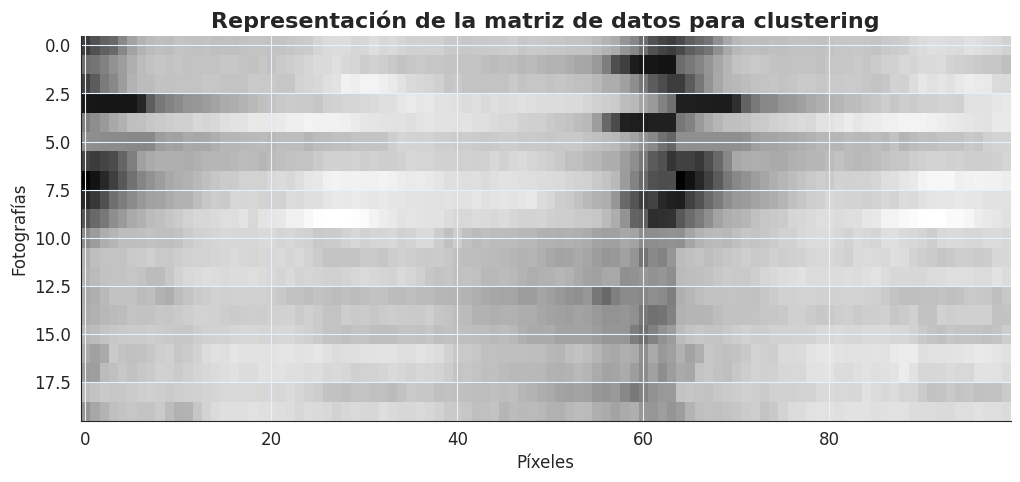

In [14]:
#Matriz
plt.figure(figsize=(12, 5))

plt.imshow(
    X_crudo[:20, :100],
    cmap="gray",
    aspect="auto"
)

plt.title(
    "Representación de la matriz de datos para clustering",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Píxeles")
plt.ylabel("Fotografías")

plt.show()

## Paso 3. Clustering con K conocido: K-medias

In [15]:
#Modelo K-medias con K=40
kmeans = KMeans(
    n_clusters=40,
    random_state=123,
    n_init=10
)

clusters = kmeans.fit_predict(X_crudo)

# Número de clusters encontrados
print("Número de clusters:", len(np.unique(clusters)))

# Número de imágenes agrupadas
print("Número de imágenes:", len(clusters))

Número de clusters: 40
Número de imágenes: 400


Con al aplicación de K-medias se dividieron las 400 fotografías en 40 clusters, de acuerdo con la configuración definida.

Sin embargo, encontrar 40 grupos no significa automáticamente que cada grupo corresponda correctamente a una persona. K-Medias siempre generará el número de clusters solicitado.

Por esta razón, es necesario evaluar la composición de los grupos utilizando las identidades reales conocidas en la base.

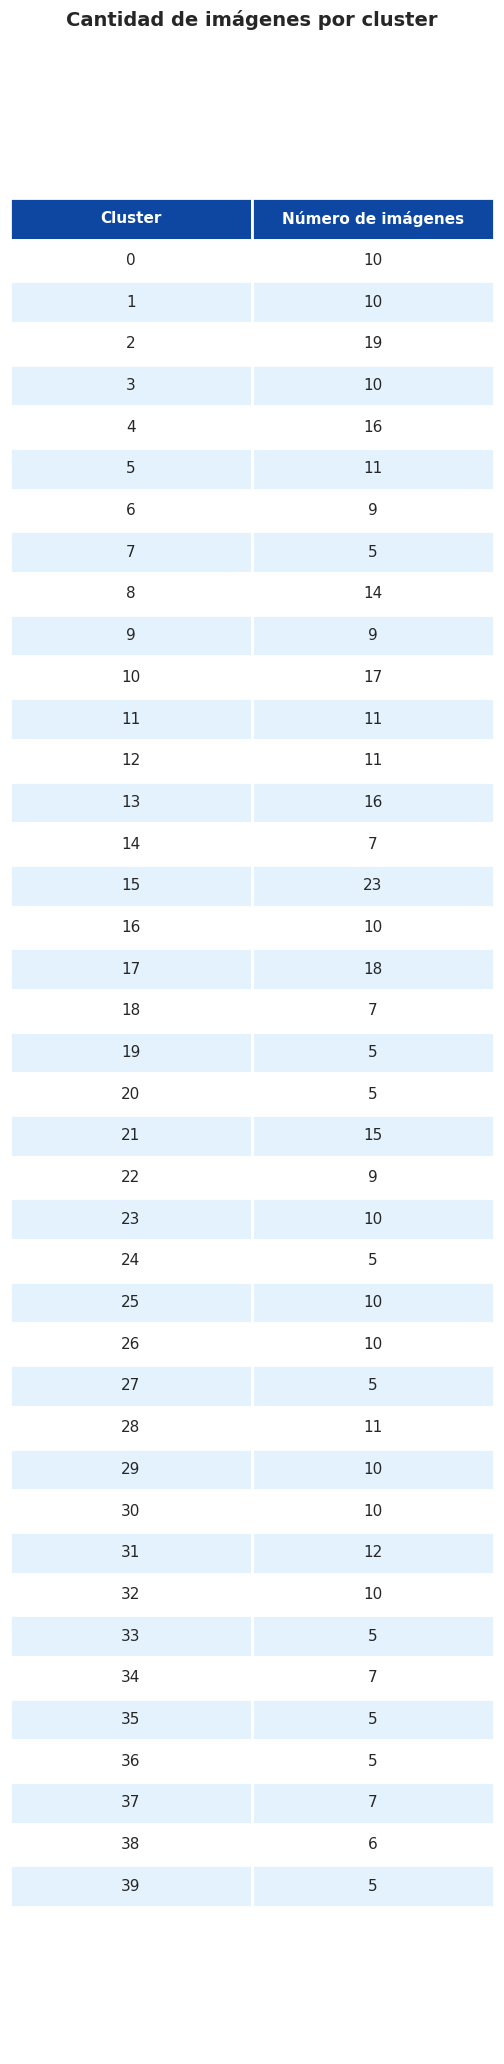

In [16]:
# Tamaño de cada cluster
tamano_clusters = pd.Series(clusters).value_counts().sort_index()

resumen_clusters = pd.DataFrame({
    "Cluster": tamano_clusters.index,
    "Número de imágenes": tamano_clusters.values
})

mostrar_tabla(
    resumen_clusters,
    "Cantidad de imágenes por cluster"
)

Por medio de la tabla se observa que los clusters no necesariamente tienen el mismo número de imágenes. Aunque cada persona tiene 10 fotografías en la base original, K-medias no conoce esta información y puede asignar un número diferente de imágenes a cada cluster.

Un cluster con muchas imágenes puede contener fotografías de varias personas, mientras que una misma persona también podría quedar dividida en diferentes clusters.

Por esta razón, el tamaño del cluster por sí solo no permite determinar si el agrupamiento fue correcto. Es necesario analizar su composición respecto a las identidades reales.

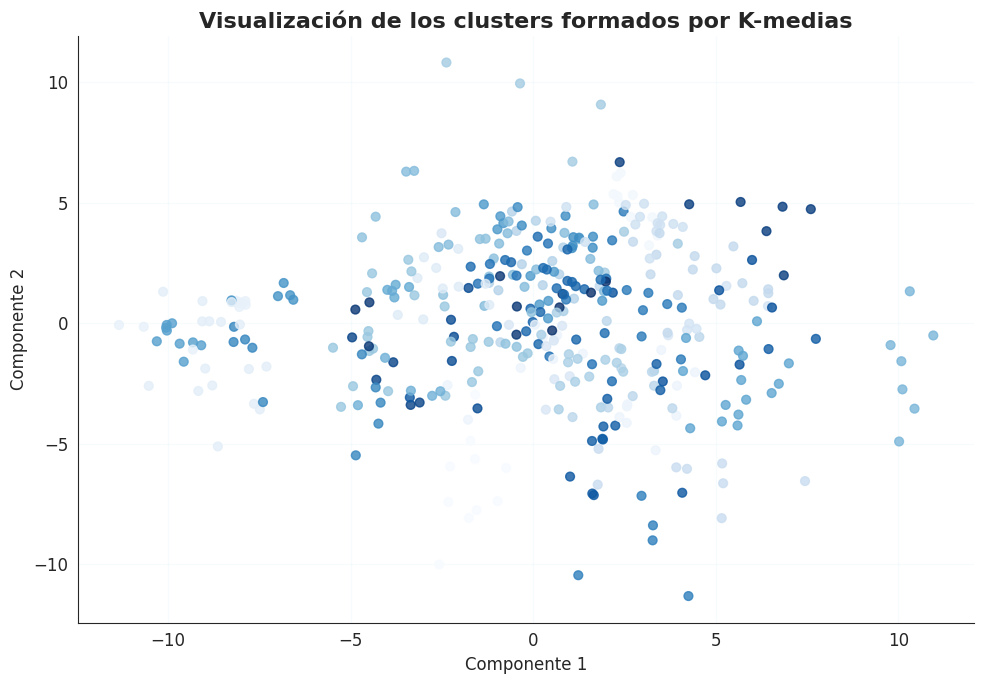

In [17]:
# Visualización de los clusters en dos dimensiones
kmeans = KMeans(
    n_clusters=40,
    random_state=123,
    n_init=10
)

cluster = kmeans.fit_predict(X_crudo)


pca_visual = PCA(n_components=2)

X_visual = pca_visual.fit_transform(X_crudo)


# Crear la nube de dispersión
plt.figure(figsize=(10, 7))

plt.scatter(
    X_visual[:, 0],
    X_visual[:, 1],
    c=cluster,
    cmap="Blues",
    s=40,
    alpha=0.8
)

plt.title(
    "Visualización de los clusters formados por K-medias",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Componente 1")
plt.ylabel("Componente 2")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

La visualización muestra que los 40 clusters formados por K-Medias no aparecen completamente separados en la proyección de dos dimensiones. Se observa una zona central con alta concentración y superposición de puntos, lo que sugiere que algunas imágenes tienen características similares y pueden ser difíciles de diferenciar.

In [18]:
def calcular_pureza(personas, clusters):

    total_correcto = 0

    for cluster in np.unique(clusters):

        # Personas que quedaron dentro del cluster
        personas_cluster = personas[clusters == cluster]

        # Persona que más aparece
        cantidad_mayor = pd.Series(personas_cluster).value_counts().max()

        total_correcto = total_correcto + cantidad_mayor

    pureza = total_correcto / len(personas)

    return pureza

pureza_crudo = calcular_pureza(personas, clusters)

print("Pureza:", round(pureza_crudo, 4))

Pureza: 0.675


In [19]:
# Coeficiente de silueta sobre píxeles crudos
silueta = silhouette_score(X_crudo, clusters)
print(f"Coeficiente de silueta (K-medias, píxeles originales, K=40): {silueta:.4f}")

Coeficiente de silueta (K-medias, píxeles originales, K=40): 0.1492


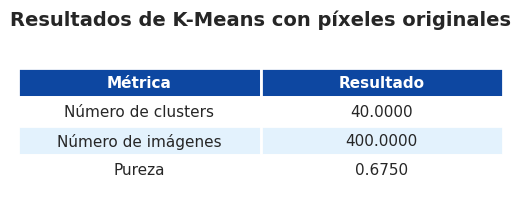

In [20]:
resultado_kmeans = pd.DataFrame({
    "Métrica": [
        "Número de clusters",
        "Número de imágenes",
        "Pureza"
    ],
    "Resultado": [
        len(np.unique(clusters)),
        len(clusters),
        pureza_crudo
    ]
})

mostrar_tabla(
    resultado_kmeans,
    "Resultados de K-Means con píxeles originales"
)

La pureza obtenida fue de **0.675**., este resultado indica que, considerando el conjunto completo de imágenes, aproximadamente **67.5%** de las fotografías pertenece a la persona más frecuente dentro de su respectivo grupo. Este resultado muestra que K-Medias logra encontrar parcialmente una estructura relacionada con la identidad de los rostros, pero todavía existe una proporción importante de imágenes que quedan mezcladas con las de otras personas.

Sin embargo, la pureza debe interpretarse junto con otras métricas y con la inspección visual de los grupos. Una pureza alta no garantiza que todas las fotografías de una misma persona hayan quedado juntas, ya que una persona podría estar dividida en varios clusters.

In [21]:
# Matriz entre identidades reales y clusters
matriz = confusion_matrix(personas, clusters)

# Buscar la mejor correspondencia
filas, columnas = linear_sum_assignment(-matriz)

# Crear las etiquetas alineadas
clusters_alineados = np.zeros_like(clusters)

for fila, columna in zip(filas, columnas):
    clusters_alineados[clusters == columna] = fila

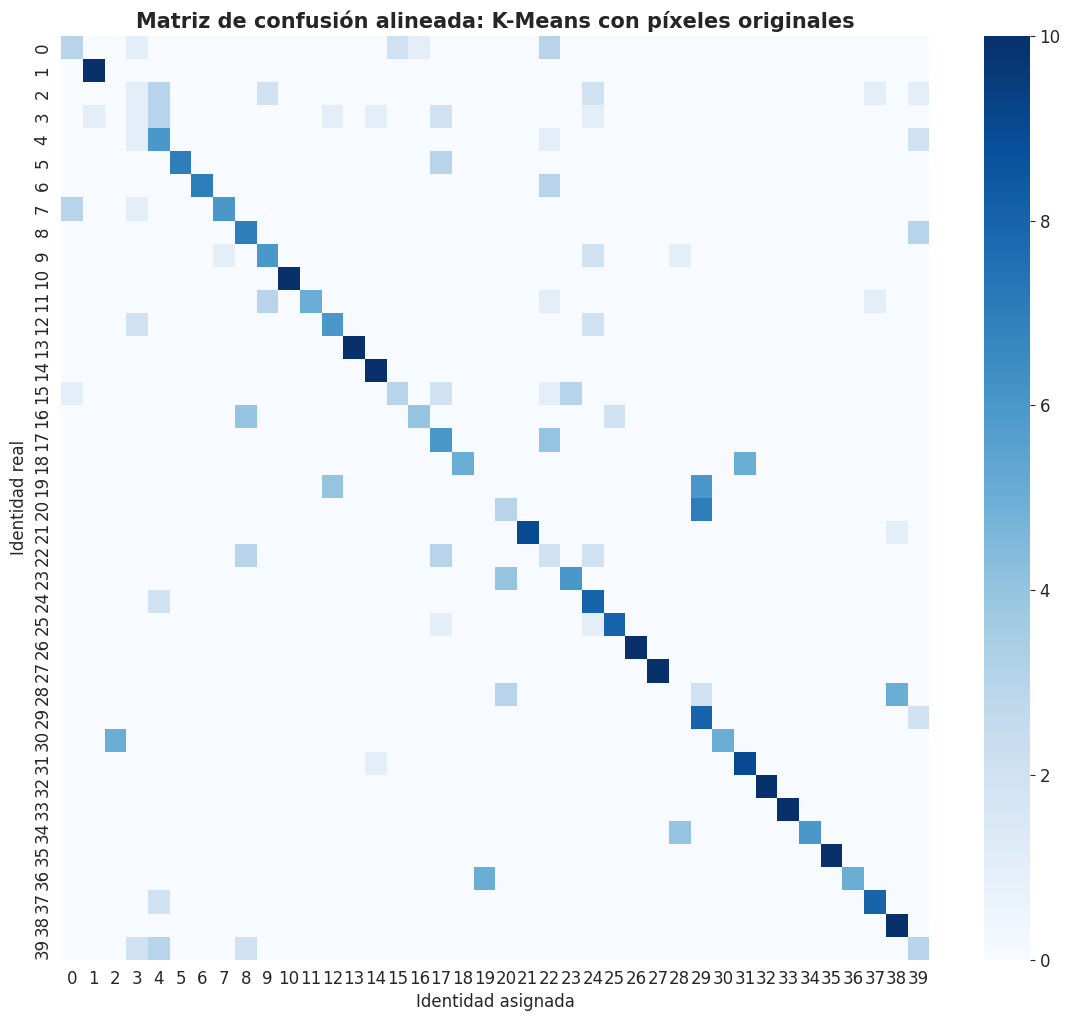

In [22]:
matriz_alineada = confusion_matrix(
    personas,
    clusters_alineados
)

plt.figure(figsize=(14, 12))

sns.heatmap(
    matriz_alineada,
    cmap="Blues",
    cbar=True
)

plt.title(
    "Matriz de confusión alineada: K-Means con píxeles originales",
    fontweight="bold"
)

plt.xlabel("Identidad asignada")
plt.ylabel("Identidad real")

plt.show()

Después de alinear los clusters con las identidades reales, la matriz de confusión permite identificar con mayor detalle qué personas fueron agrupadas correctamente y cuáles presentan mayores dificultades de separación.

Los valores concentrados en la diagonal representan las imagénes que coinciden con su identidad correspondiente. En la matriz se observa una concentración importante de resultados sobre esta diagonal, lo que indica que K-MEdias logra separar correctamente algunas identidades.

Sin embargo, también aparecen valores fuera de la diagonal. Estos representan fotografías que fueron agrupadas junto con una identidad diferente, evidenciando mezclas entre personas.

Porcentaje de coincidencias después de la alineación: 63.0 %


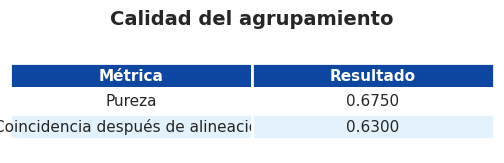

In [23]:
coincidencias = np.mean(
    personas == clusters_alineados
)

print(
    "Porcentaje de coincidencias después de la alineación:",
    round(coincidencias * 100, 2),
    "%"
)

resumen_calidad = pd.DataFrame({
    "Métrica": [
        "Pureza",
        "Coincidencia después de alineación"
    ],
    "Resultado": [
        pureza_crudo,
        coincidencias
    ]
})

mostrar_tabla(
    resumen_calidad,
    "Calidad del agrupamiento"
)

La pureza alcanzó un valor de **67.5%**, mientras que la coincidencia después de alinear los clusters con las identidades reales fue de **63%**.

La diferencia entre ambas métricas es esperada, ya que la pureza evalúa cuál es la identidad predominante dentro de cada cluster, mientras que la alineación establece una correspondencia única entre clusters y personas.

En conjunto, los resultados muestran que K-Medias puede recuperar parte de la estructura de las identidades, pero todavía comete una cantidad importante de errores. Aproximadamente 37 de cada 100 imágenes no coinciden con la identidad asignada después de la alineación.


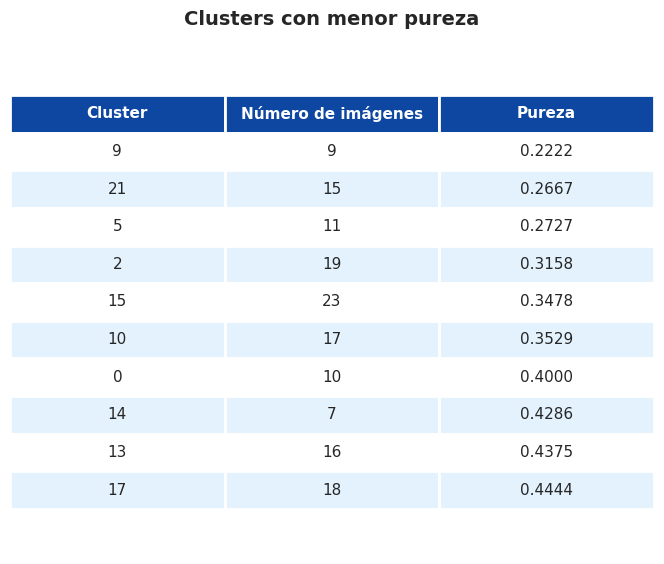

In [24]:
purezas_clusters = []

for cluster in np.unique(clusters):

    personas_cluster = personas[clusters == cluster]

    cantidad_mayor = pd.Series(
        personas_cluster
    ).value_counts().max()

    pureza = cantidad_mayor / len(personas_cluster)

    purezas_clusters.append([
        cluster,
        len(personas_cluster),
        pureza
    ])

purezas_clusters = pd.DataFrame(
    purezas_clusters,
    columns=[
        "Cluster",
        "Número de imágenes",
        "Pureza"
    ]
)

purezas_clusters = purezas_clusters.sort_values(
    "Pureza"
)

mostrar_tabla(
    purezas_clusters.head(10),
    "Clusters con menor pureza"
)

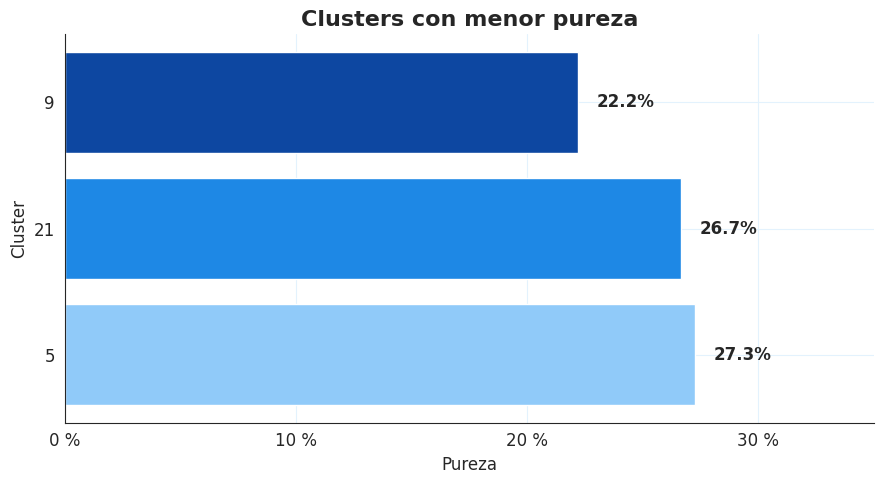

In [25]:
# Datos de los 3 clusters con menor pureza
clusters_peores = pd.DataFrame({
    "Cluster": [9, 21, 5],
    "Pureza": [0.2222, 0.2667, 0.2727]
})

# Crear gráfica
plt.figure(figsize=(9, 5))

plt.barh(
    clusters_peores["Cluster"].astype(str),
    clusters_peores["Pureza"],
    color=["#0D47A1", "#1E88E5", "#90CAF9"]
)

# Cluster más problemático arriba
plt.gca().invert_yaxis()

# Título y etiquetas
plt.title(
    "Clusters con menor pureza",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Pureza")
plt.ylabel("Cluster")

# Mostrar el eje como porcentaje
plt.xlim(0, 0.35)
plt.xticks(
    [0, 0.1, 0.2, 0.3],
    ["0 %", "10 %", "20 %", "30 %"]
)

# Agregar porcentaje al final de cada barra
for i, pureza in enumerate(clusters_peores["Pureza"]):
    plt.text(
        pureza + 0.008,
        i,
        f"{pureza:.1%}",
        va="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

La revisión individual de clusters muestra que el desempeño de K-Medias no es igual entre todos los grupos.

El caso más crítico es el **cluster 9**, con una pureza de apenas **0.22**. Esto significa que la identidad más frecuente representa solamente alrededor del 22,2 % de las imágenes de ese grupo, lo que evidencia una mezcla importante entre diferentes personas.

También se observan otros clusters con purezas inferiores al 30 % y al 40 %. Estos resultados confirman que la pureza general de 67,5 % oculta diferencias grandes entre los grupos: algunos clusters pueden ser relativamente homogéneos, mientras que otros mezclan varias identidades.

Cluster seleccionado: 9.0


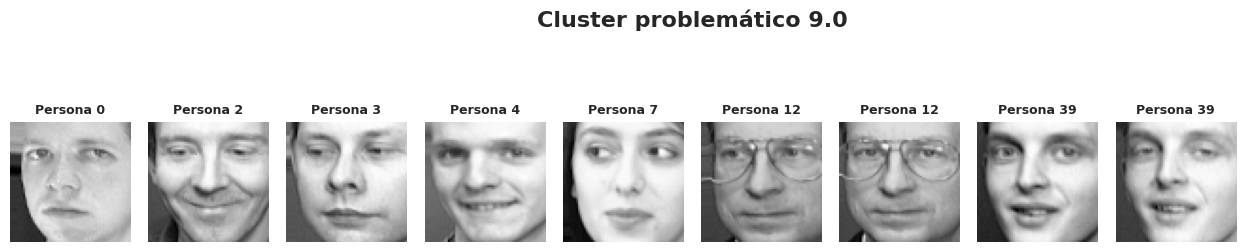

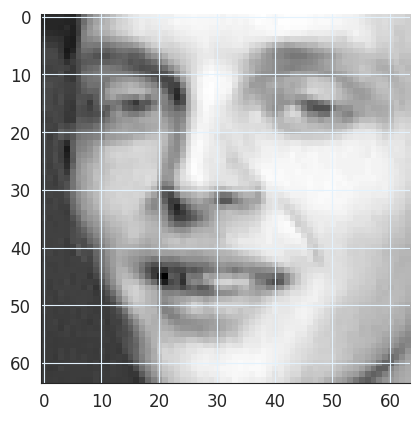

In [26]:
cluster_problema = purezas_clusters.iloc[0]["Cluster"]

print("Cluster seleccionado:", cluster_problema)

posiciones = np.where(
    clusters == cluster_problema
)[0]

plt.figure(figsize=(14, 6))

for i, posicion in enumerate(posiciones):

    plt.subplot(2, 10, i + 1)

    plt.imshow(
        imagenes[posicion],
        cmap="gray"
    )

    plt.title(
        f"Persona {personas[posicion]}",
        fontsize=9
    )

    plt.axis("off")

plt.suptitle(
    f"Cluster problemático {cluster_problema}",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

plt.imshow(imagenes[posicion], cmap="gray")

La inspección visual confirma el resultado de la pureza. El **cluster 9** contiene imagénes correspondientes a varias personas diferentes, por lo que no representa una identidad claramente definida.

Aunque algunas imágenes pueden compartir características visuales generales, como una iluminación similar, orientación del rostro o ciertos patrones de contraste, pertenecen a personas distintas.

Este resultado muestra una de las principales limitaciones de trabajar directamente con los 4.096 píxeles. K-Medias agrupa las imágenes según las distancias entre sus valores numéricos y no comprende directamente el concepto de identidad facial.

Por esta razón, cambios en la iluminación, la pose o la expresión pueden tener un peso importante en la distancia entre imágenes y provocar que rostros diferentes sean considerados similares.

Clusters seleccionados: [9, 21, 5]


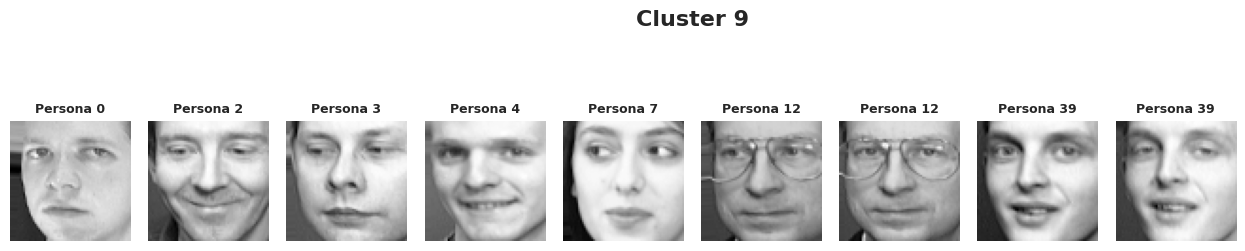

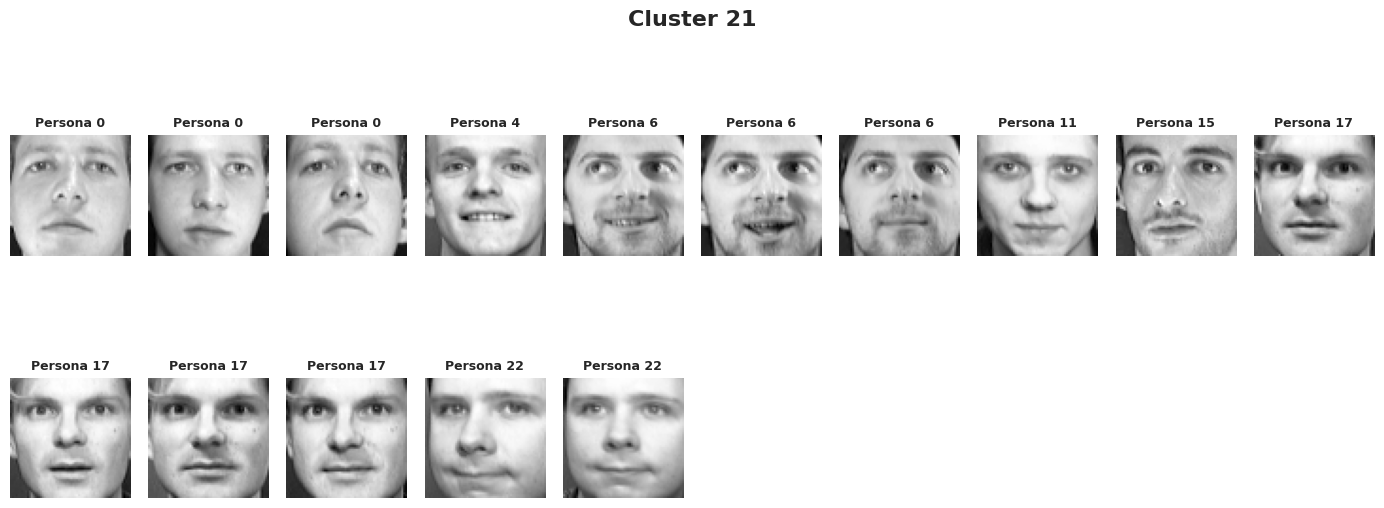

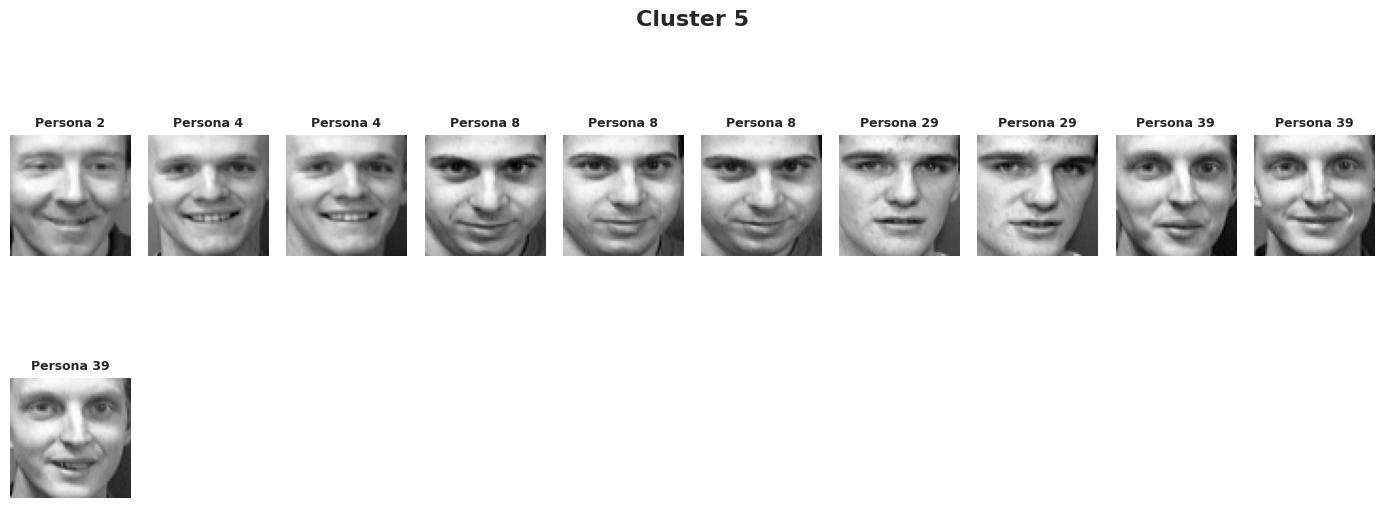

In [27]:
clusters_problema = purezas_clusters.head(3)["Cluster"].tolist()

print("Clusters seleccionados:", clusters_problema)

for cluster_problema in clusters_problema:

    posiciones = np.where(
        clusters == cluster_problema
    )[0]

    plt.figure(figsize=(14, 6))

    for i, posicion in enumerate(posiciones):

        plt.subplot(2, 10, i + 1)

        plt.imshow(
            imagenes[posicion],
            cmap="gray"
        )

        plt.title(
            f"Persona {personas[posicion]}",
            fontsize=9
        )

        plt.axis("off")

    plt.suptitle(
        f"Cluster {cluster_problema}",
        fontsize=16,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

La revisión de los clusters **9**, **21** y **5** confirma que los grupos con menor pureza presentan mezclas importantes entre diferentes personas.

La inspección visual refuerza los resultados obtenidos mediante las métricas: K-MEdias aplicado directamente sobre los píxeles crudos logra identificar cierta estructura de similitud, pero esta similitud no siempre corresponde a la identidad de la persona.

Las variaciones visuales presentes en las imagénes, junto con la alta dimensionalidad de los datos, dificultan que las distancias entre píxeles representen adecuadamente la similitud facial de una persona.

## Paso 4. Reducción de dimensión: impacto de PCA

In [28]:
# Ajustar PCA para retener 95% de varianza
pca = PCA(n_components=0.95, random_state=123)
X_pca = pca.fit_transform(X_crudo)

n_componentes = pca.n_components_
print(f"Número de componentes para explicar el 95% de la varianza: {n_componentes}")
print(f"Dimensión original: {X_crudo.shape[1]} píxeles")
print(f"Dimensión reducida: {X_pca.shape[1]} componentes")
print(f"Reducción: {(1 - X_pca.shape[1]/X_crudo.shape[1])*100:.1f}%")

Número de componentes para explicar el 95% de la varianza: 123
Dimensión original: 4096 píxeles
Dimensión reducida: 123 componentes
Reducción: 97.0%


Al aplicar PCA conservando el 95% de la varianza, las imágenes pueden representarse con un número considerablemente menor de variables que los 4.096 píxeles originales. Esto permite simplificar la información utilizada por el modelo y evaluar si una representación más compacta logra reducir el efecto de la alta dimensionalidad sin perder demasiada información relevante para diferenciar los rostros de cada persona.

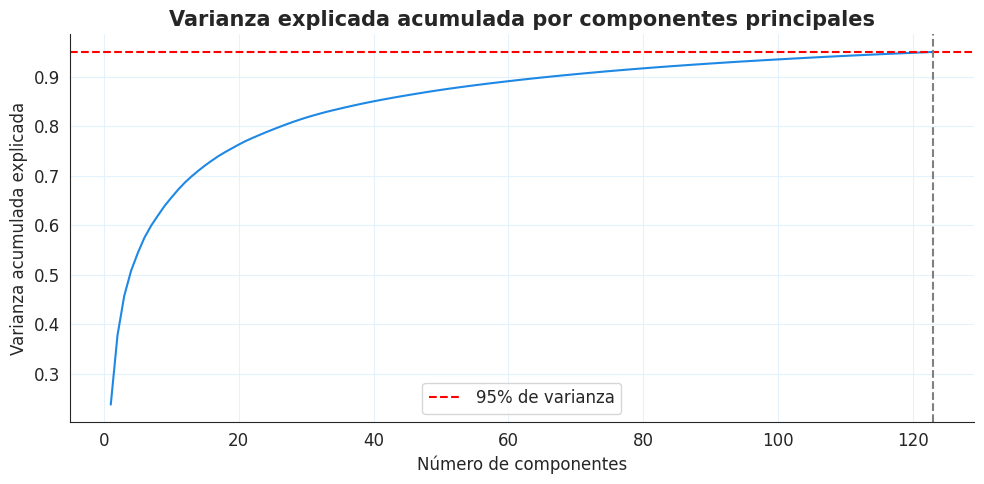

In [29]:
# Gráfica de varianza explicada acumulada
varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, color=AZUL)
plt.axhline(y=0.95, color="red", linestyle="--", label="95% de varianza")
plt.axvline(x=n_componentes, color="gray", linestyle="--")
plt.title("Varianza explicada acumulada por componentes principales")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada explicada")
plt.legend()
plt.tight_layout()
plt.show()

La gráfica confirma que la varianza explicada aumenta rápidamente al incorporar componentes principales y que, con 123 componentes, se alcanza el objetivo de conservar aproximadamente el 95% de la variabilidad de las imágenes. Esto respalda la decisión de utilizar esta representación reducida en el siguiente análisis de clustering.

In [30]:
# Repetir K-medias sobre las coordenadas PCA
kmeans_pca = KMeans(
    n_clusters=40,
    random_state=123,
    n_init=10
)
clusters_pca = kmeans_pca.fit_predict(X_pca)

# Pureza y silueta sobre PCA
pureza_pca = calcular_pureza(personas, clusters_pca)
silueta_pca = silhouette_score(X_pca, clusters_pca)

print(f"\nPureza (K-medias, PCA, K=40): {pureza_pca:.4f}")
print(f"Coeficiente de silueta (K-medias, PCA, K=40): {silueta_pca:.4f}")



Pureza (K-medias, PCA, K=40): 0.6450
Coeficiente de silueta (K-medias, PCA, K=40): 0.1726


Ahora se aplica K-Medias utilizando las 123 componentes obtenidas con PCA y manteniendo K=40, para hacer una comparación directa con el modelo aplicado anteriormente sobre los píxeles originales.

Con PCA, la pureza obtenida fue de 64,5%, lo que indica que todavía existe mezcla de diferentes identidades dentro de algunos clusters. Por otra parte, la silueta fue de 0,1726, ligeramente superior a la obtenida con los píxeles originales. Esto sugiere que PCA mejoró un poco la separación de los clusters, aunque todavía debemos verificar si esa mejora también se traduce en una mejor correspondencia con las identidades reales.

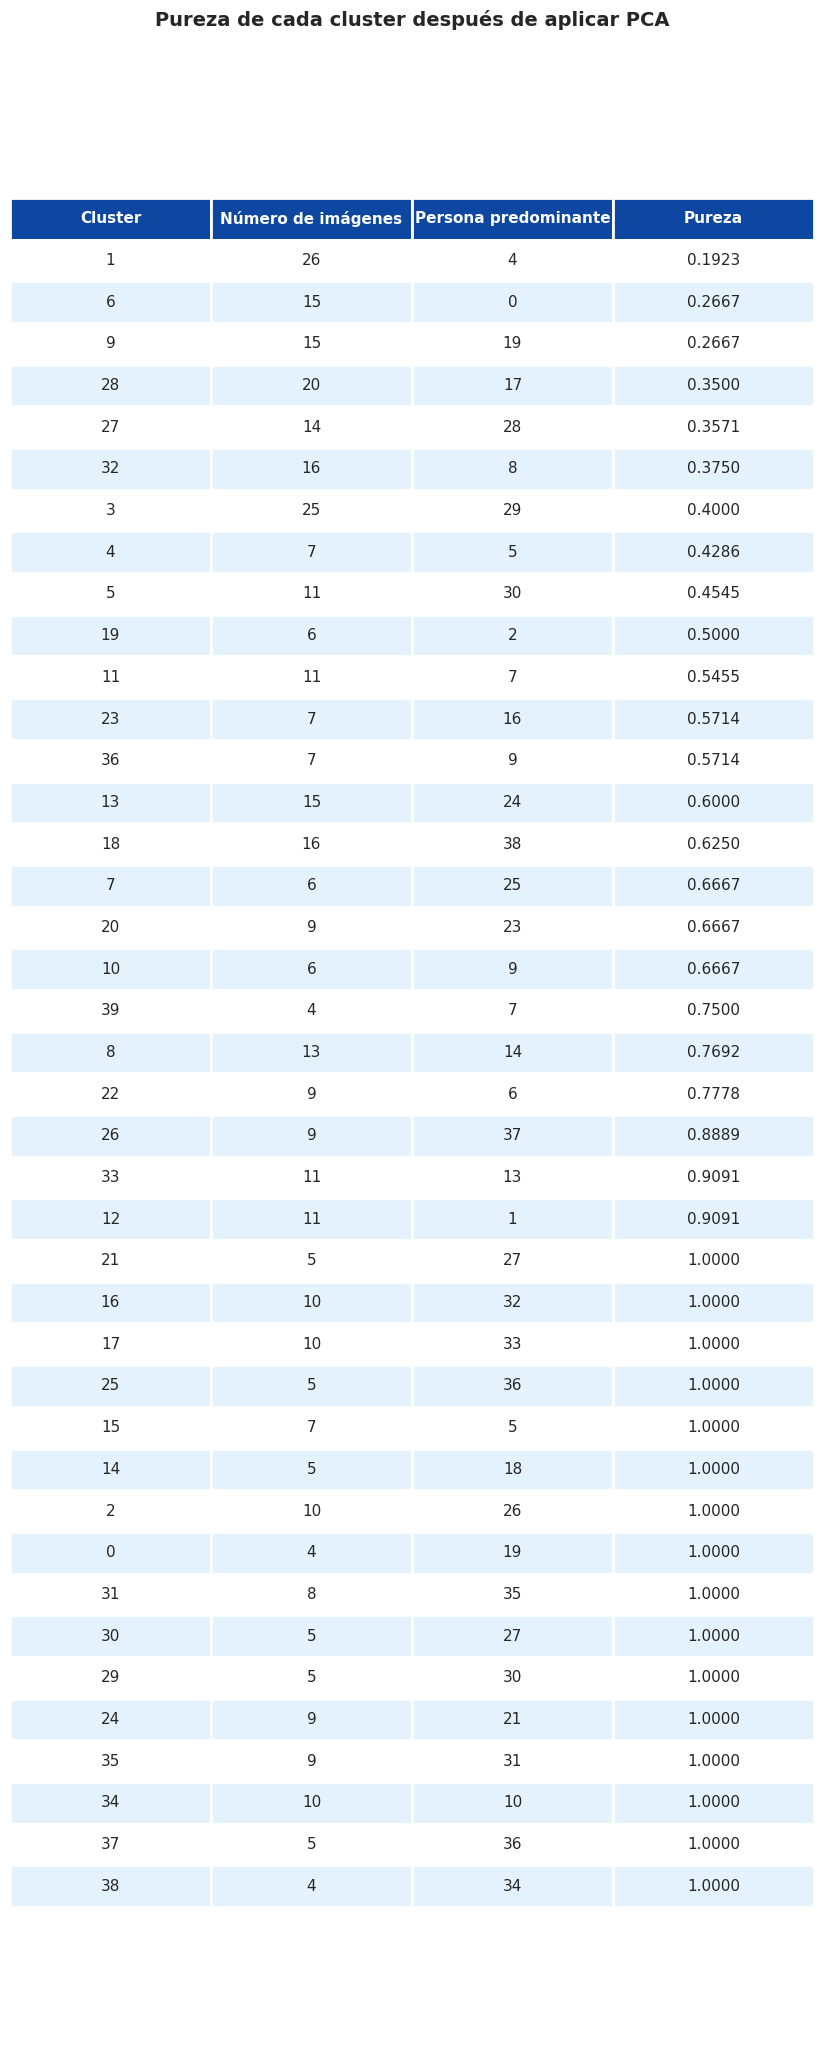

In [31]:
# Calcular la pureza de cada cluster obtenido con PCA
pureza_por_cluster_pca = []

for cluster in range(40):

    # Personas que quedaron dentro del cluster
    personas_cluster = personas[clusters_pca == cluster]

    # Cantidad de imágenes de cada persona
    valores, cantidades = np.unique(
        personas_cluster,
        return_counts=True
    )

    # Persona predominante
    persona_principal = valores[np.argmax(cantidades)]

    # Pureza del cluster
    pureza_cluster = np.max(cantidades) / len(personas_cluster)

    pureza_por_cluster_pca.append([
        cluster,
        len(personas_cluster),
        persona_principal,
        pureza_cluster
    ])


tabla_pureza_pca = pd.DataFrame(
    pureza_por_cluster_pca,
    columns=[
        "Cluster",
        "Número de imágenes",
        "Persona predominante",
        "Pureza"
    ]
)

tabla_pureza_pca = tabla_pureza_pca.sort_values(
    "Pureza"
)

mostrar_tabla(
    tabla_pureza_pca,
    "Pureza de cada cluster después de aplicar PCA"
)

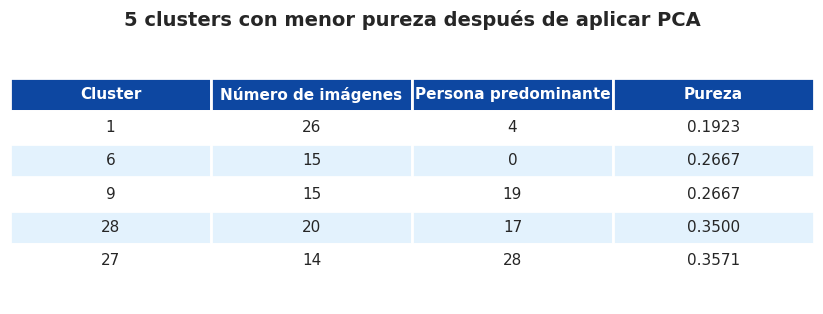

In [32]:
# Mostrar los 5 clusters con menor pureza
peores_clusters_pca = tabla_pureza_pca.head(5)

mostrar_tabla(
    peores_clusters_pca,
    "5 clusters con menor pureza después de aplicar PCA"
)

La tabla de pureza permite identificar cómo varía la calidad entre los diferentes clusters. Algunos grupos están formados principalmente por una sola identidad, mientras que otros presentan una mayor mezcla de personas.

Los clusters con menor pureza representan los casos más problemáticos del modelo, ya que contienen una mayor proporción de fotografías pertenecientes a personas diferentes. Estos grupos son especialmente importantes para evaluar la viabilidad del clustering en el problema de negocio, porque una mezcla elevada podría llevar a un analista a revisar fotografías de identidades incorrectas dentro de un mismo grupo.

Porcentaje de coincidencias después de la alineación (PCA): 59.25%


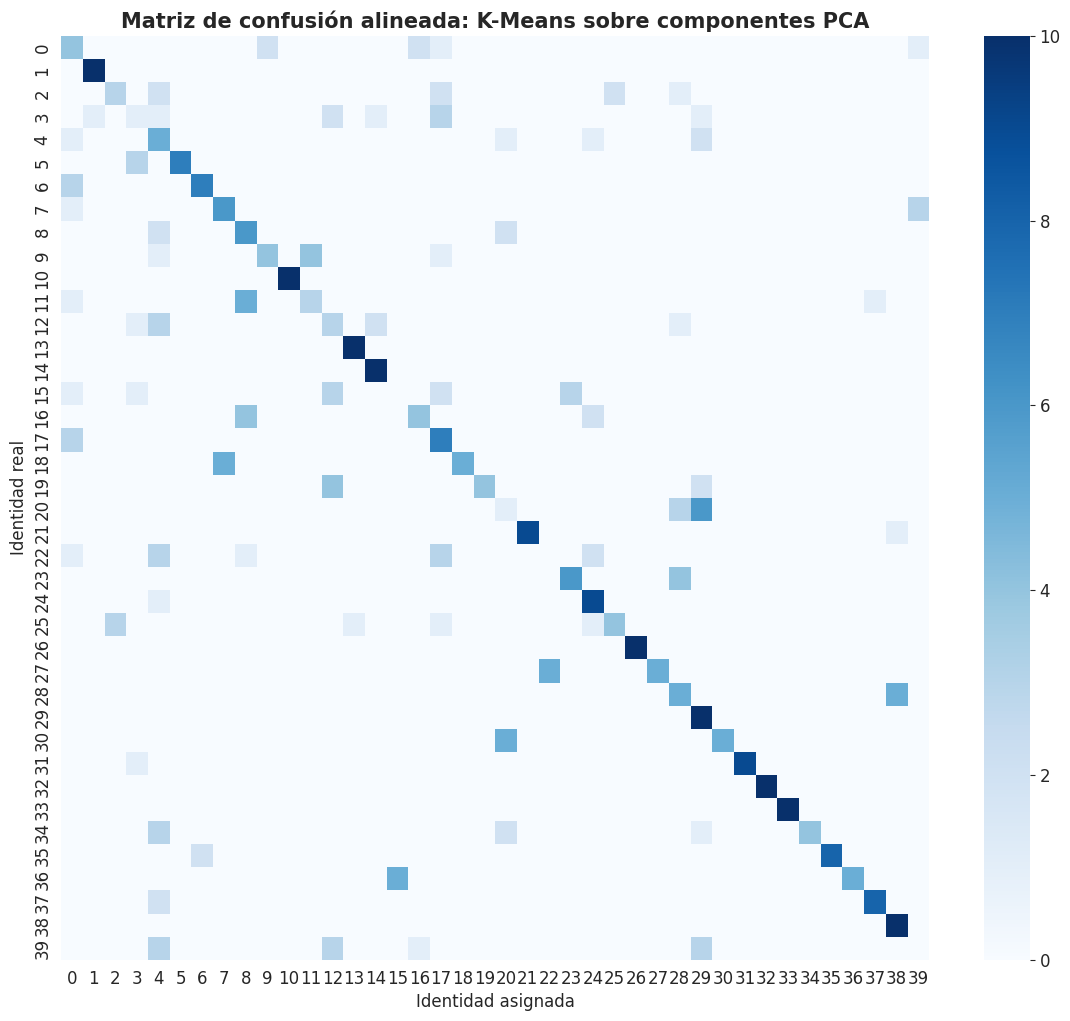

In [33]:
# Matriz de confusión alineada sobre PCA
matriz_pca = confusion_matrix(personas, clusters_pca)
filas_pca, columnas_pca = linear_sum_assignment(-matriz_pca)

clusters_alineados_pca = np.zeros_like(clusters_pca)
for fila, columna in zip(filas_pca, columnas_pca):
    clusters_alineados_pca[clusters_pca == columna] = fila

coincidencias_pca = np.mean(personas == clusters_alineados_pca)
print(f"Porcentaje de coincidencias después de la alineación (PCA): {round(coincidencias_pca*100, 2)}%")

matriz_alineada_pca = confusion_matrix(personas, clusters_alineados_pca)

plt.figure(figsize=(14, 12))
sns.heatmap(matriz_alineada_pca, cmap="Blues", cbar=True)
plt.title("Matriz de confusión alineada: K-Means sobre componentes PCA", fontweight="bold")
plt.xlabel("Identidad asignada")
plt.ylabel("Identidad real")
plt.show()


Después de encontrar la mejor correspondencia posible entre los clusters y las identidades reales, el modelo alcanza una coincidencia del 59,25%. Esto significa que la agrupación todavía no logra asociar correctamente una proporción importante de las fotografías con su identidad real.

La matriz permite confirmar que PCA no eliminó completamente la mezcla entre personas y que una mejor separación de los clusters no garantiza necesariamente una mejor identificación de los rostros.

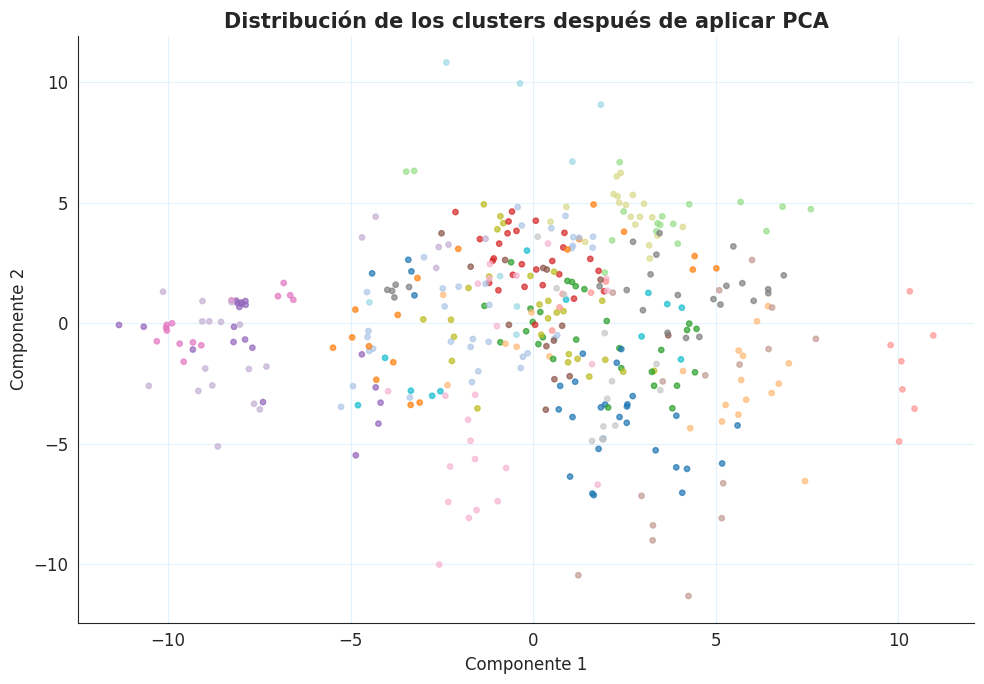

In [34]:
# Visualización de los clusters
pca_2d = PCA(n_components=2, random_state=123)

X_pca_2d = pca_2d.fit_transform(X_pca)

plt.figure(figsize=(10, 7))

plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=clusters_pca,
    cmap="tab20",
    s=15,
    alpha=0.7
)

plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.title("Distribución de los clusters después de aplicar PCA")

plt.tight_layout()
plt.show()

La gráfica permite observar cómo se distribuyen visualmente las fotografías. Los diferentes colores corresponden a los clusters asignados por K-Medias. Aunque algunos grupos pueden mostrar zonas de concentración, también pueden existir áreas de superposición entre clusters, lo que ayuda a explicar por qué la separación de las identidades no es perfecta.

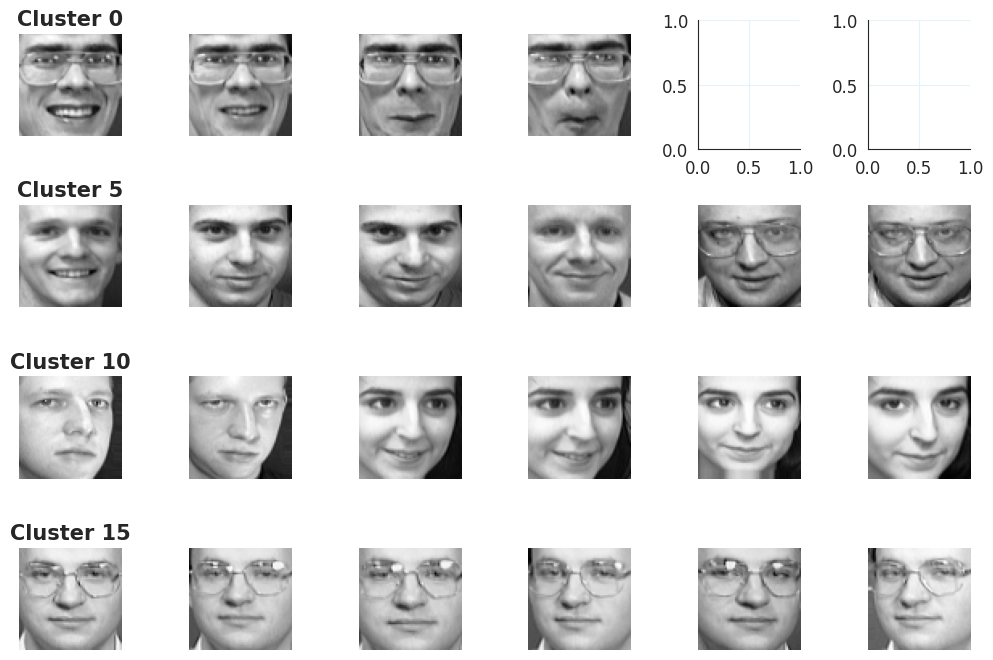

In [35]:
# Seleccionar algunos clusters para inspección visual

clusters_ejemplo = [0, 5, 10, 15]

fig, axes = plt.subplots(
    len(clusters_ejemplo),
    6,
    figsize=(10, 7)
)

for fila, cluster in enumerate(clusters_ejemplo):

    # Buscar las imágenes que pertenecen al cluster
    indices = np.where(clusters_pca == cluster)[0]

    # Mostrar máximo 6 imágenes
    for columna, indice in enumerate(indices[:6]):

        axes[fila, columna].imshow(
            imagenes[indice],
            cmap="gray"
        )

        axes[fila, columna].axis("off")

        if columna == 0:
            axes[fila, columna].set_title(
                f"Cluster {cluster}"
            )

plt.tight_layout()
plt.show()

La inspección visual permite comprobar que efectivamente en los clusters se están mezclando varias personas diferentes, el modelo no esta reconociendo y asigando correctamente las imágenes de cada personas.

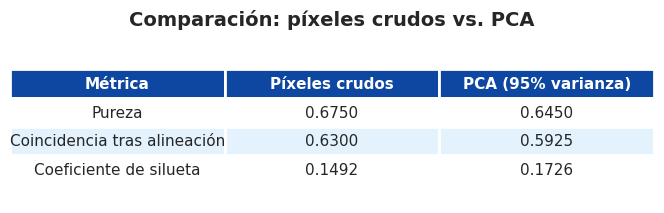

In [36]:
# Comparación de resultados: crudo vs PCA
comparacion_pca = pd.DataFrame({
    "Métrica": ["Pureza", "Coincidencia tras alineación", "Coeficiente de silueta"],
    "Píxeles crudos": [pureza_crudo, coincidencias, silueta],
    "PCA (95% varianza)": [pureza_pca, coincidencias_pca, silueta_pca]
})
mostrar_tabla(comparacion_pca, "Comparación: píxeles crudos vs. PCA")

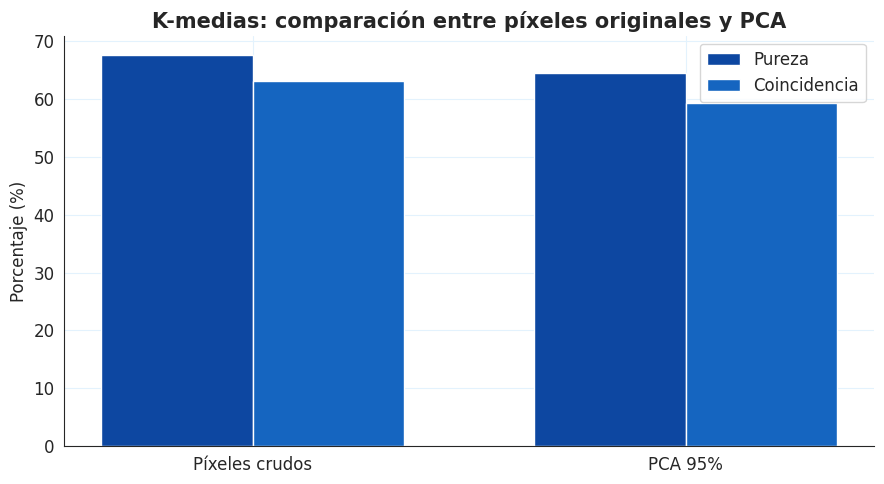

In [37]:
# Comparación visual: K-medias crudo vs. PCA
modelos = ["Píxeles crudos", "PCA 95%"]

purezas = [
    pureza_crudo * 100,
    pureza_pca * 100
]

coincidencias_grafica = [
    coincidencias * 100,
    coincidencias_pca * 100
]

x = np.arange(len(modelos))
ancho = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - ancho/2,
    purezas,
    width=ancho,
    label="Pureza"
)

plt.bar(
    x + ancho/2,
    coincidencias_grafica,
    width=ancho,
    label="Coincidencia"
)

plt.xticks(x, modelos)
plt.ylabel("Porcentaje (%)")
plt.title("K-medias: comparación entre píxeles originales y PCA")
plt.legend()

plt.tight_layout()
plt.show()

La comparación muestra que PCA no mejoró las métricas relacionadas directamente con la identificación de las personas. La pureza disminuyó de 67,5% a 64,5% y la coincidencia después de la alineación pasó de 63% a 59,25%. Por tanto, aunque PCA simplificó considerablemente la representación de las imágenes perdió parte de la información útil para diferenciar correctamente las identidades.

## Paso 5. K-medoides: robustez a outliers

In [38]:
!pip install scikit-learn-extra -q
from sklearn_extra.cluster import KMedoids

# K-medoides sobre píxeles originales
kmedoids_crudo = KMedoids(
    n_clusters=40,
    random_state=123,
    method="pam"
)
clusters_medoides_crudo = kmedoids_crudo.fit_predict(X_crudo)

# Mostrar cuántas imágenes quedaron en cada cluster
tamano_clusters_medoides = pd.Series(
    clusters_medoides_crudo
).value_counts().sort_index()

print("Número de clusters encontrados:", len(tamano_clusters_medoides))
print()
print("Cantidad de imágenes por cluster:")
print(tamano_clusters_medoides)

Número de clusters encontrados: 40

Cantidad de imágenes por cluster:
0      5
1      5
2     10
3     13
4     37
5      8
6      4
7     18
8      4
9      4
10     7
11     5
12     5
13    10
14     5
15    13
16    20
17     9
18    14
19     8
20     5
21    10
22     7
23     9
24    11
25     4
26    10
27     9
28    18
29    18
30     4
31    18
32     9
33     3
34    10
35    14
36     5
37    15
38     5
39    12
Name: count, dtype: int64


K-medoides agrupó las fotografías en 40 clusters, manteniendo el mismo número de grupos utilizado previamente en K-Medias. Cada cluster representa un conjunto de imágenes que el algoritmo considera similares. En esta primera ejecución trabajamos directamente con los píxeles originales de las fotografías.

K-Medoides sobre píxeles originales
Pureza: 0.6475
Coincidencia tras alineación: 0.5775
Coeficiente de silueta: 0.1447


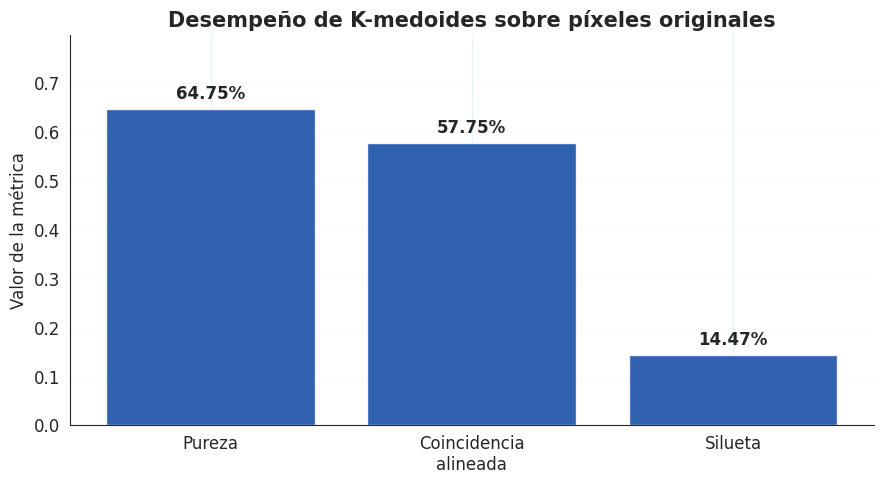

In [39]:
pureza_medoides_crudo = calcular_pureza(personas, clusters_medoides_crudo)
silueta_medoides_crudo = silhouette_score(X_crudo, clusters_medoides_crudo)

matriz_mc = confusion_matrix(personas, clusters_medoides_crudo)
filas_mc, columnas_mc = linear_sum_assignment(-matriz_mc)
clusters_alineados_mc = np.zeros_like(clusters_medoides_crudo)
for fila, columna in zip(filas_mc, columnas_mc):
    clusters_alineados_mc[clusters_medoides_crudo == columna] = fila
coincidencias_medoides_crudo = np.mean(personas == clusters_alineados_mc)

print("K-Medoides sobre píxeles originales")
print(f"Pureza: {pureza_medoides_crudo:.4f}")
print(f"Coincidencia tras alineación: {coincidencias_medoides_crudo:.4f}")
print(f"Coeficiente de silueta: {silueta_medoides_crudo:.4f}")

# Preparar las métricas para la visualización

metricas_medoides = pd.DataFrame({
    "Métrica": [
        "Pureza",
        "Coincidencia\nalineada",
        "Silueta"
    ],
    "Valor": [
        pureza_medoides_crudo,
        coincidencias_medoides_crudo,
        silueta_medoides_crudo
    ]
})


# Crear gráfica de barras
plt.figure(figsize=(9, 5))

plt.bar(
    metricas_medoides["Métrica"],
    metricas_medoides["Valor"],
    alpha=0.85
)


# Agregar el valor sobre cada barra
for i, valor in enumerate(metricas_medoides["Valor"]):

    plt.text(
        i,
        valor + 0.02,
        f"{valor:.2%}",
        ha="center",
        fontweight="bold"
    )


plt.title(
    "Desempeño de K-medoides sobre píxeles originales",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel("Valor de la métrica")

plt.ylim(
    0,
    min(1.1, max(metricas_medoides["Valor"]) + 0.15)
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()
plt.show()

K-medoides logró una pureza de 64,75 %, por lo que los clusters reúnen mayoritariamente imágenes de una misma persona. Sin embargo, la coincidencia alineada bajó a 57,75 %, lo que evidencia que todavía existe una cantidad importante de fotografías asignadas a grupos incorrectos. Además, la silueta de 0,1447 muestra una separación débil entre los clusters, indicando que las personas presentan características visuales similares que el modelo no logra diferenciar completamente.

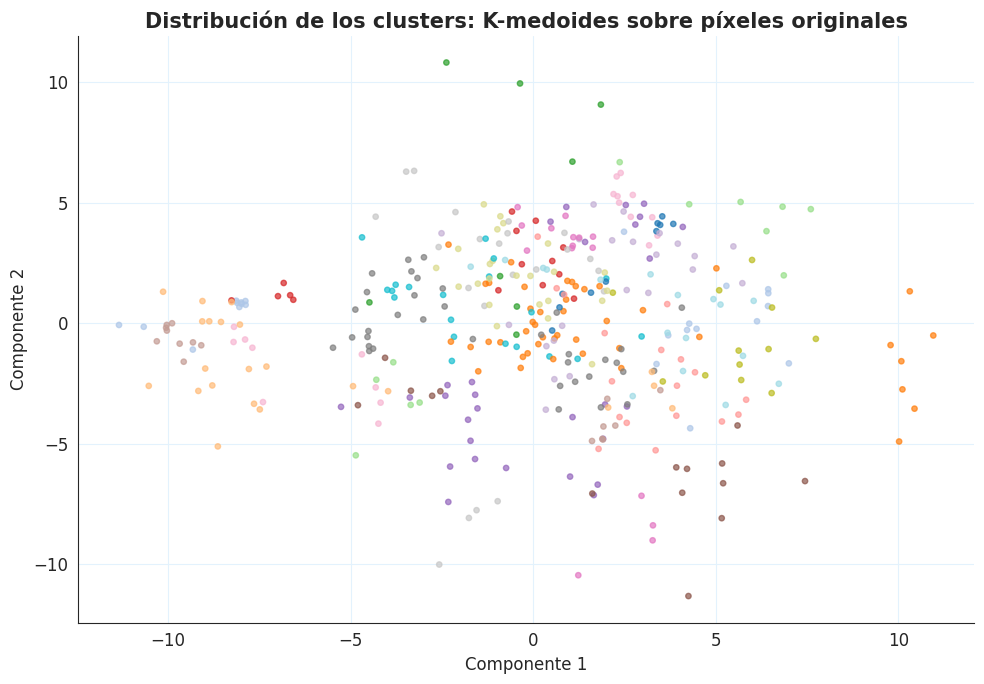

In [40]:
#visualización de los clusters
pca_medoides_2d = PCA(
    n_components=2,
    random_state=123
)

X_medoides_2d = pca_medoides_2d.fit_transform(
    X_crudo
)


# Visualización de los clusters encontrados por K-medoides

plt.figure(figsize=(10, 7))

plt.scatter(
    X_medoides_2d[:, 0],
    X_medoides_2d[:, 1],
    c=clusters_medoides_crudo,
    cmap="tab20",
    s=15,
    alpha=0.7
)

plt.xlabel("Componente 1")
plt.ylabel("Componente 2")

plt.title(
    "Distribución de los clusters: K-medoides sobre píxeles originales",
    fontweight="bold"
)

plt.tight_layout()
plt.show()

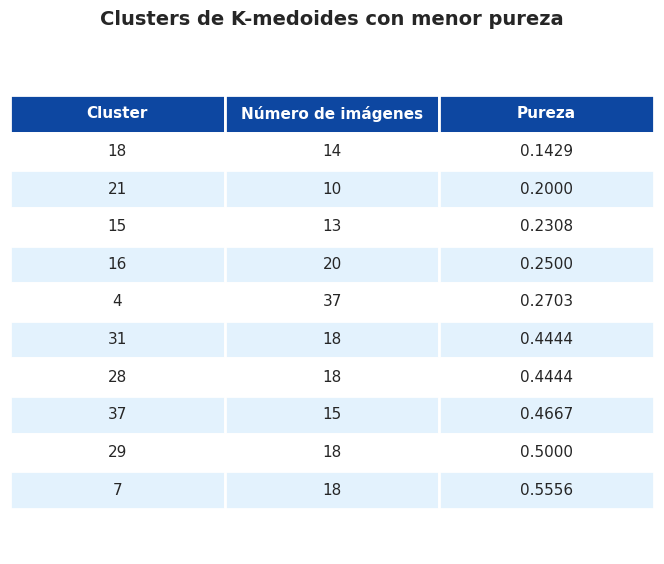

In [41]:
purezas_clusters_medoides = []

for cluster in np.unique(clusters_medoides_crudo):

    personas_cluster = personas[
        clusters_medoides_crudo == cluster
    ]

    cantidad_mayor = pd.Series(
        personas_cluster
    ).value_counts().max()

    pureza = cantidad_mayor / len(personas_cluster)

    purezas_clusters_medoides.append([
        cluster,
        len(personas_cluster),
        pureza
    ])


purezas_clusters_medoides = pd.DataFrame(
    purezas_clusters_medoides,
    columns=[
        "Cluster",
        "Número de imágenes",
        "Pureza"
    ]
)

purezas_clusters_medoides = purezas_clusters_medoides.sort_values(
    "Pureza"
)

mostrar_tabla(
    purezas_clusters_medoides.head(10),
    "Clusters de K-medoides con menor pureza"
)

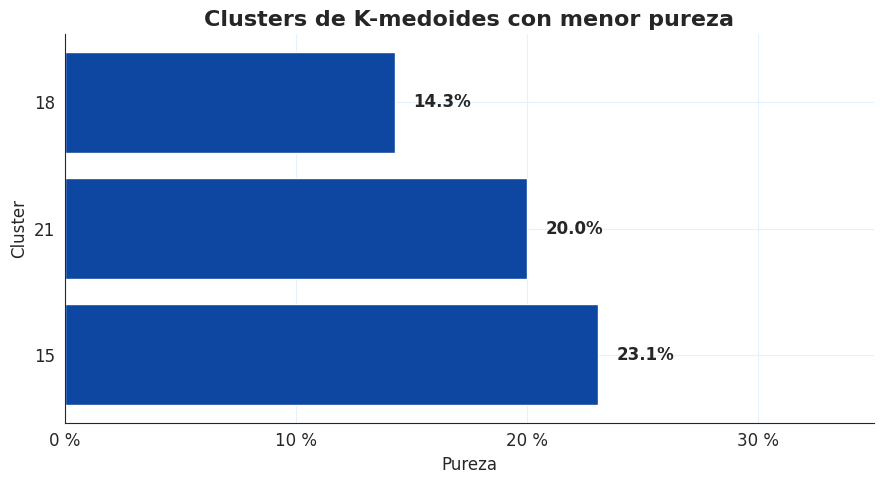

In [42]:
# Seleccionar los 3 clusters con menor pureza

clusters_peores_medoides = (
    purezas_clusters_medoides
    .head(3)
    .copy()
)


# Crear gráfica

plt.figure(figsize=(9, 5))

plt.barh(
    clusters_peores_medoides["Cluster"].astype(str),
    clusters_peores_medoides["Pureza"]
)

plt.gca().invert_yaxis()

plt.title(
    "Clusters de K-medoides con menor pureza",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Pureza")
plt.ylabel("Cluster")

plt.xlim(0, 0.35)

plt.xticks(
    [0, 0.1, 0.2, 0.3],
    ["0 %", "10 %", "20 %", "30 %"]
)


# Mostrar porcentaje

for i, pureza in enumerate(
    clusters_peores_medoides["Pureza"]
):

    plt.text(
        pureza + 0.008,
        i,
        f"{pureza:.1%}",
        va="center",
        fontweight="bold"
    )


plt.tight_layout()
plt.show()

Clusters seleccionados: [18, 21, 15]


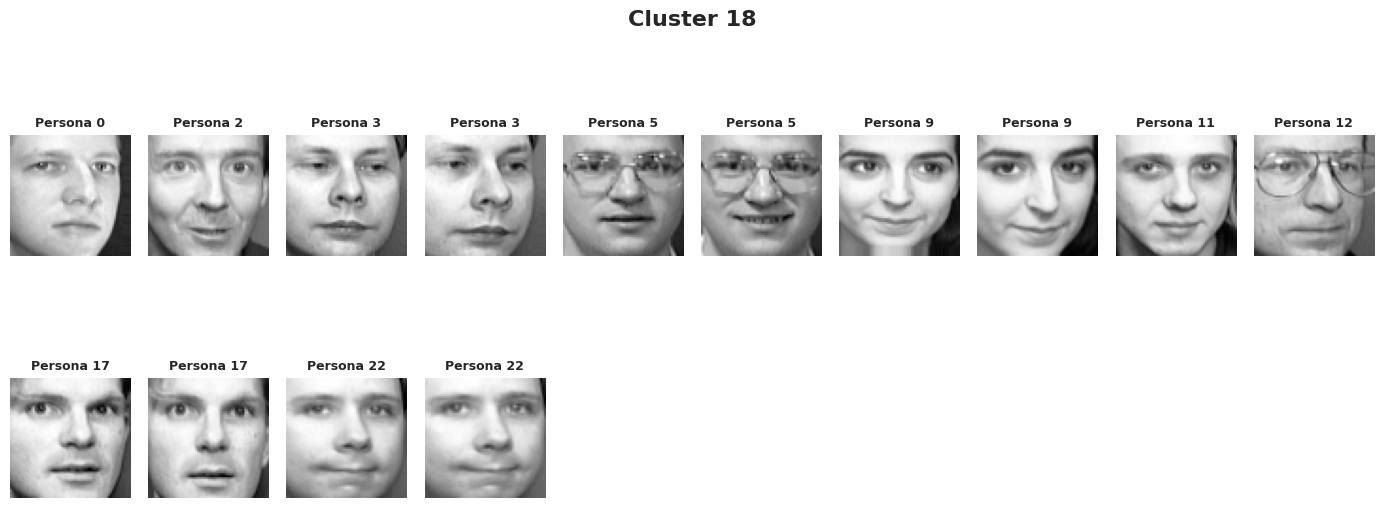

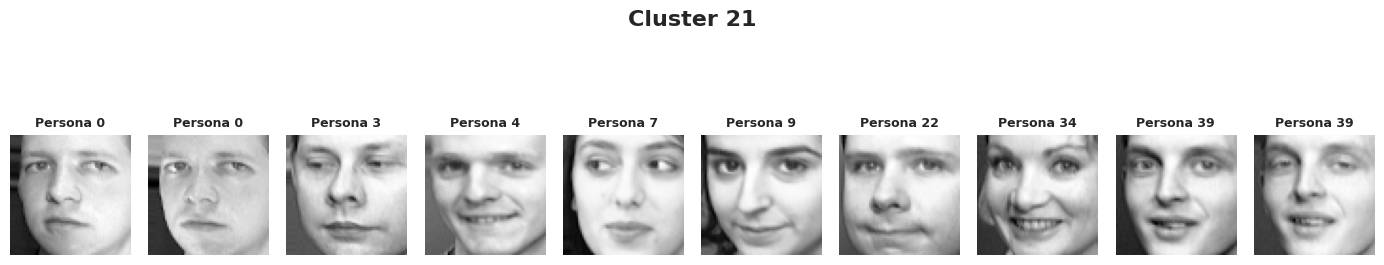

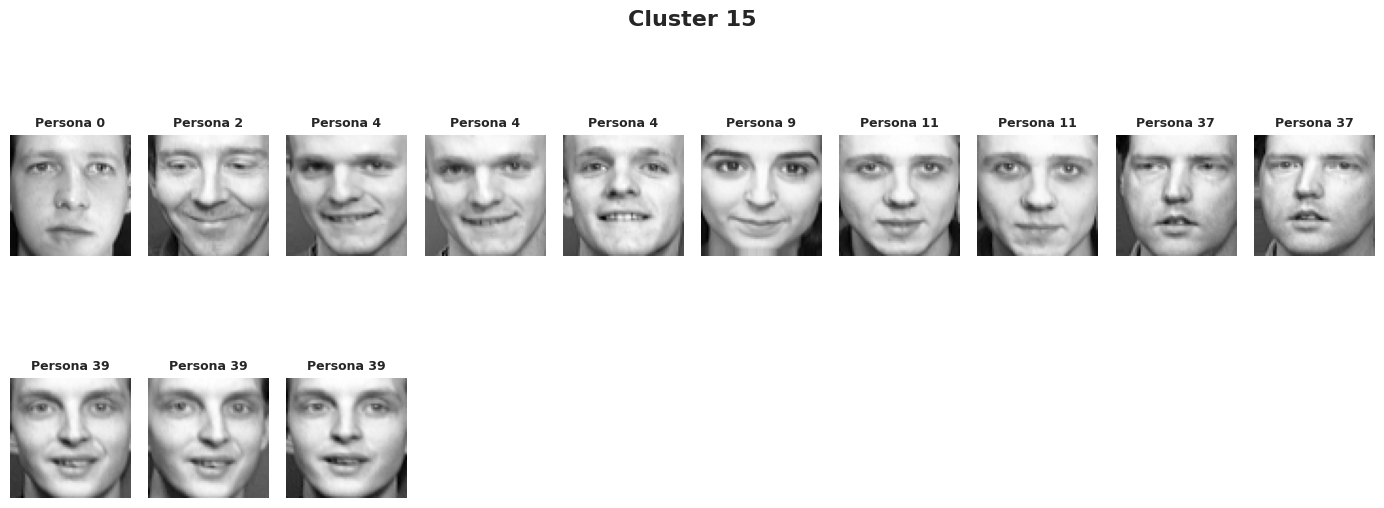

In [43]:
# Seleccionar los 3 clusters con menor pureza

clusters_problema_medoides = (
    purezas_clusters_medoides
    .head(3)["Cluster"]
    .tolist()
)

print(
    "Clusters seleccionados:",
    clusters_problema_medoides
)


for cluster_problema in clusters_problema_medoides:

    posiciones = np.where(
        clusters_medoides_crudo == cluster_problema
    )[0]

    plt.figure(figsize=(14, 6))

    for i, posicion in enumerate(posiciones):

        plt.subplot(2, 10, i + 1)

        plt.imshow(
            imagenes[posicion],
            cmap="gray"
        )

        plt.title(
            f"Persona {personas[posicion]}",
            fontsize=9
        )

        plt.axis("off")

    plt.suptitle(
        f"Cluster {cluster_problema}",
        fontsize=16,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

In [44]:
# K-medoides sobre componentes PCA
kmedoids_pca = KMedoids(
    n_clusters=40,
    random_state=123,
    method="pam"
)
clusters_medoides_pca = kmedoids_pca.fit_predict(X_pca)

In [45]:
pureza_medoides_pca = calcular_pureza(personas, clusters_medoides_pca)
silueta_medoides_pca = silhouette_score(X_pca, clusters_medoides_pca)

matriz_mp = confusion_matrix(personas, clusters_medoides_pca)
filas_mp, columnas_mp = linear_sum_assignment(-matriz_mp)
clusters_alineados_mp = np.zeros_like(clusters_medoides_pca)
for fila, columna in zip(filas_mp, columnas_mp):
    clusters_alineados_mp[clusters_medoides_pca == columna] = fila
coincidencias_medoides_pca = np.mean(personas == clusters_alineados_mp)

print("\nK-medoides sobre componentes PCA")
print(f"Pureza: {pureza_medoides_pca:.4f}")
print(f"Coincidencia tras alineación: {coincidencias_medoides_pca:.4f}")
print(f"Coeficiente de silueta: {silueta_medoides_pca:.4f}")


K-medoides sobre componentes PCA
Pureza: 0.6400
Coincidencia tras alineación: 0.5700
Coeficiente de silueta: 0.1642


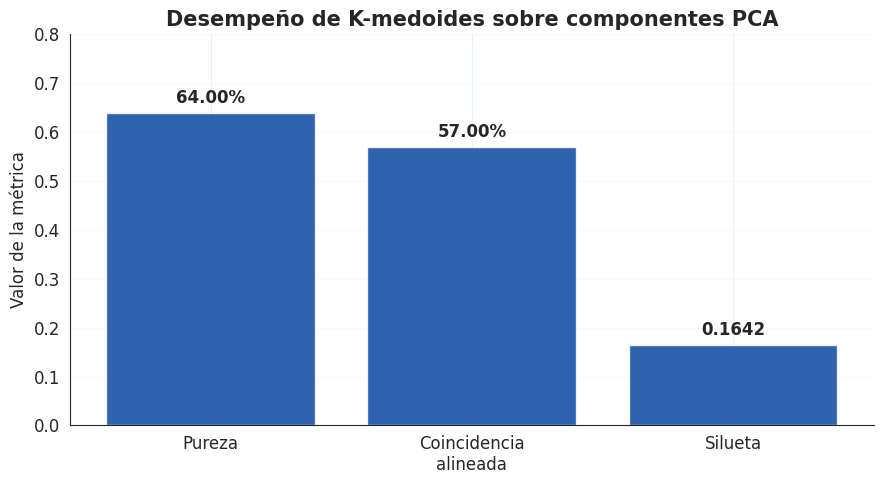

In [46]:
# Preparar las métricas para visualizar el desempeño
metricas_medoides_pca = pd.DataFrame({
    "Métrica": [
        "Pureza",
        "Coincidencia\nalineada",
        "Silueta"
    ],
    "Valor": [
        pureza_medoides_pca,
        coincidencias_medoides_pca,
        silueta_medoides_pca
    ]
})


# Crear gráfica

plt.figure(figsize=(9, 5))

plt.bar(
    metricas_medoides_pca["Métrica"],
    metricas_medoides_pca["Valor"],
    alpha=0.85
)


# Mostrar el valor de cada métrica

for i, valor in enumerate(metricas_medoides_pca["Valor"]):

    if i == 2:
        texto = f"{valor:.4f}"
    else:
        texto = f"{valor:.2%}"

    plt.text(
        i,
        valor + 0.02,
        texto,
        ha="center",
        fontweight="bold"
    )


plt.title(
    "Desempeño de K-medoides sobre componentes PCA",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel("Valor de la métrica")

plt.ylim(0, 0.8)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()
plt.show()

Al aplicar K-medoides sobre las componentes PCA, la pureza disminuyó a **64%**, mientras que la coincidencia se mantuvo prácticamente igual en **57%.** La silueta aumentó ligeramente a 0,1642, lo que indica una mejor separación interna de los clusters, pero sin mejorar la identificación de las personas. Por tanto, PCA organiza ligeramente mejor los grupos, aunque no aumenta su correspondencia con las identidades reales.

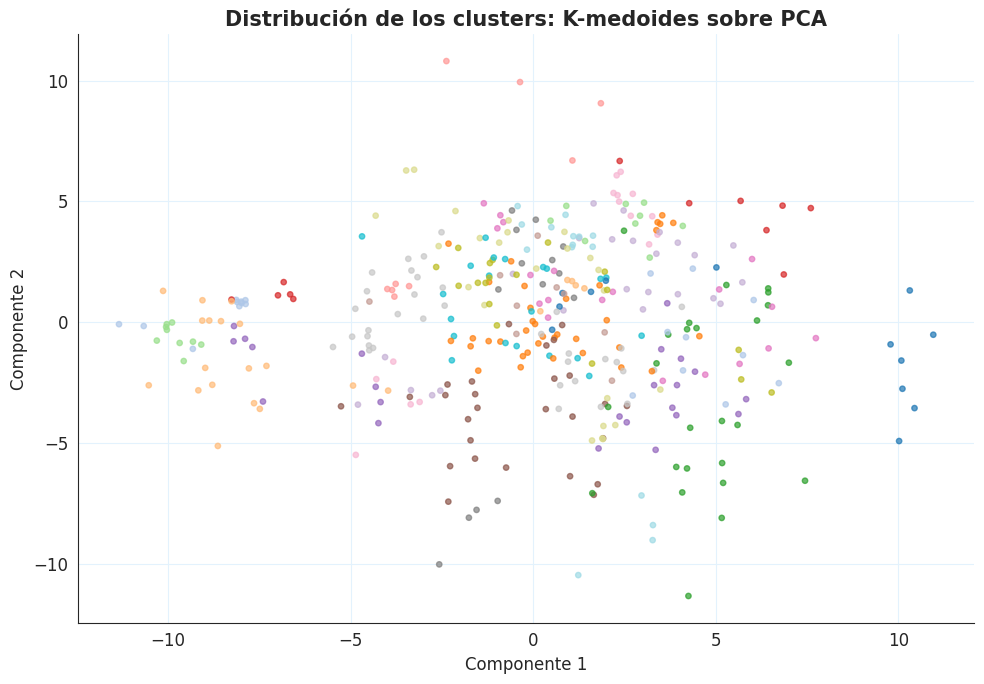

In [47]:
# Visualización de los clusters

pca_medoides_pca_2d = PCA(
    n_components=2,
    random_state=123
)

X_medoides_pca_2d = pca_medoides_pca_2d.fit_transform(
    X_pca
)


# Visualizar los clusters encontrados por K-medoides + PCA

plt.figure(figsize=(10, 7))

plt.scatter(
    X_medoides_pca_2d[:, 0],
    X_medoides_pca_2d[:, 1],
    c=clusters_medoides_pca,
    cmap="tab20",
    s=15,
    alpha=0.7
)

plt.xlabel("Componente 1")
plt.ylabel("Componente 2")

plt.title(
    "Distribución de los clusters: K-medoides sobre PCA",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

La representación muestra que los clusters de K-medoides + PCA se concentran principalmente en una zona central, pero con una alta superposición entre colores. Esto indica que, aunque PCA logró una ligera mejora en la separación general, todavía no existen fronteras visuales claramente definidas entre muchos grupos.

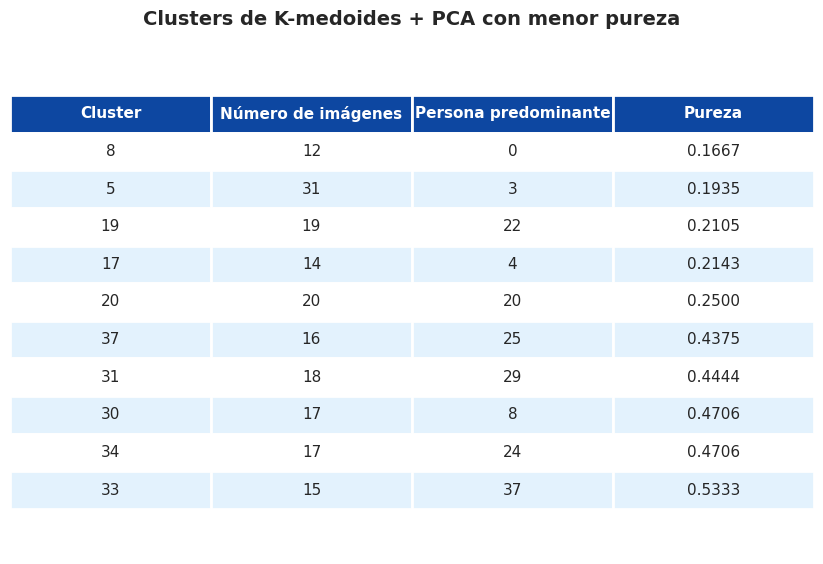

In [48]:
# Calcular la pureza individual de cada cluster

pureza_por_cluster_medoides_pca = []

for cluster in np.unique(clusters_medoides_pca):

    personas_cluster = personas[
        clusters_medoides_pca == cluster
    ]

    valores, cantidades = np.unique(
        personas_cluster,
        return_counts=True
    )

    persona_principal = valores[
        np.argmax(cantidades)
    ]

    pureza_cluster = (
        np.max(cantidades) / len(personas_cluster)
    )

    pureza_por_cluster_medoides_pca.append([
        cluster,
        len(personas_cluster),
        persona_principal,
        pureza_cluster
    ])


tabla_pureza_medoides_pca = pd.DataFrame(
    pureza_por_cluster_medoides_pca,
    columns=[
        "Cluster",
        "Número de imágenes",
        "Persona predominante",
        "Pureza"
    ]
)


tabla_pureza_medoides_pca = tabla_pureza_medoides_pca.sort_values(
    "Pureza"
)


mostrar_tabla(
    tabla_pureza_medoides_pca.head(10),
    "Clusters de K-medoides + PCA con menor pureza"
)

Clusters seleccionados: [8, 5, 19]


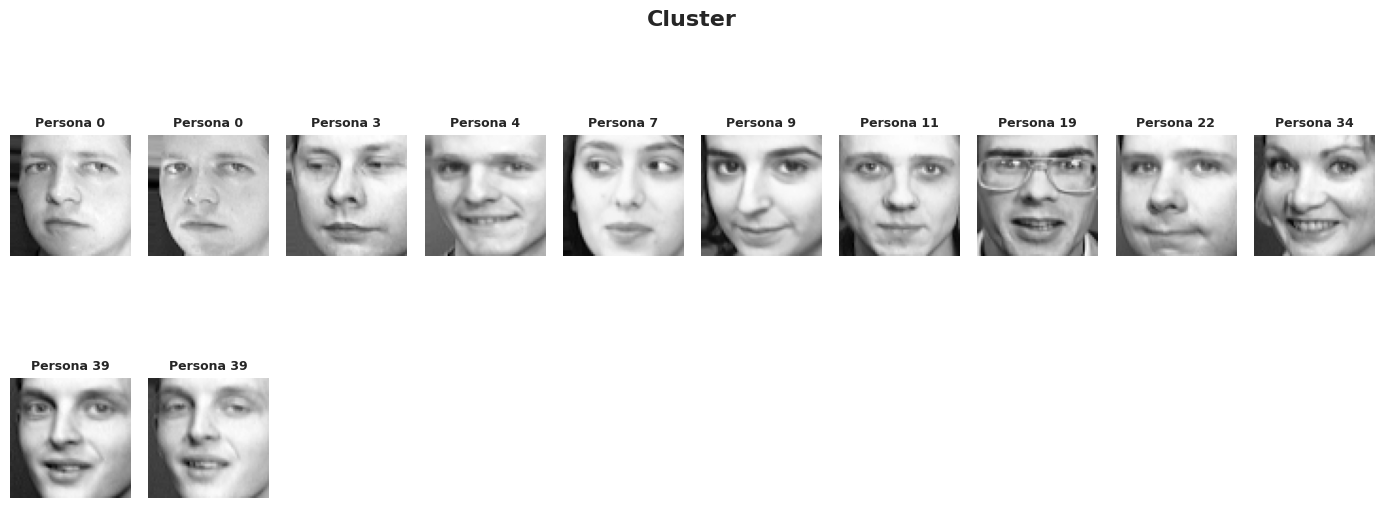

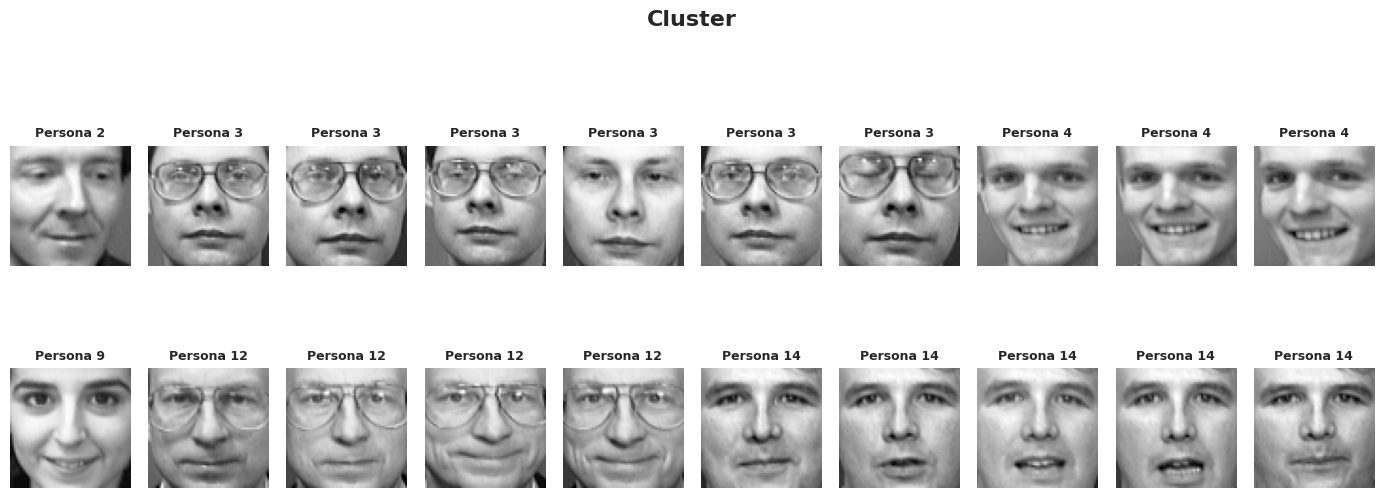

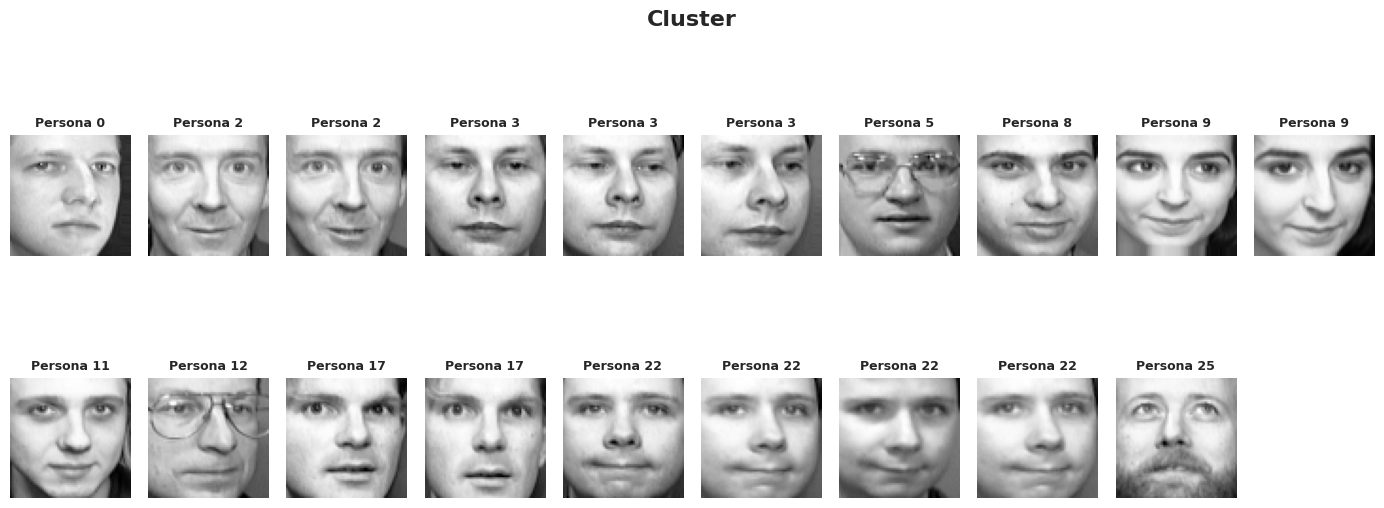

In [49]:
# Seleccionar los 3 clusters con menor pureza

clusters_problema_medoides_pca = (
    tabla_pureza_medoides_pca
    .head(3)["Cluster"]
    .tolist()
)

print(
    "Clusters seleccionados:",
    clusters_problema_medoides_pca
)


# Mostrar las imágenes reales de cada cluster

for cluster_problema in clusters_problema_medoides_pca:

    posiciones = np.where(
        clusters_medoides_pca == cluster_problema
    )[0]

    plt.figure(figsize=(14, 6))

    for i, posicion in enumerate(posiciones[:20]): # Limitar a 20 imágenes para el subplot 2x10

        plt.subplot(2, 10, i + 1)

        plt.imshow(
            imagenes[posicion],
            cmap="gray"
        )

        plt.title(
            f"Persona {personas[posicion]}",
            fontsize=9
        )

        plt.axis("off")


    plt.suptitle(
        f"Cluster",
        fontsize=16,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

Los clusters menos puros presentan una fuerte mezcla de personas. El caso más crítico es el cluster 8, donde la persona predominante representa apenas el **16,67%** de sus 12 imágenes. Además, el cluster 5 reúne 31 fotografías y su persona predominante solo alcanza el **19.35%**, lo que evidencia que K-medoides + PCA está agrupando imágenes visualmente similares que pertenecen a diferentes empleados.

La inspección visual confirma el problema identificado por la pureza: dentro de los clusters aparecen fotografías de diferentes personas. El algoritmo parece estar agrupando principalmente por similitud visual de ciertos rasgos *(posición del rostro, iluminación o elementos como las gafas)*, y no exclusivamente por la identidad del empleado.

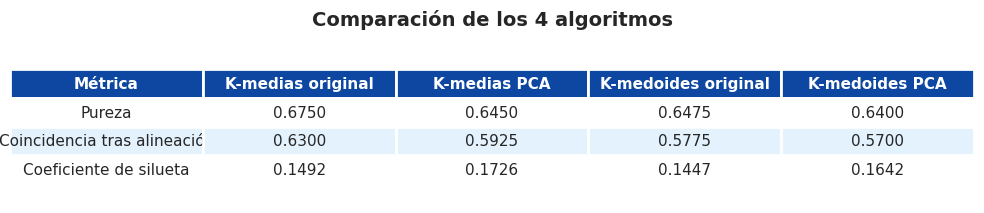

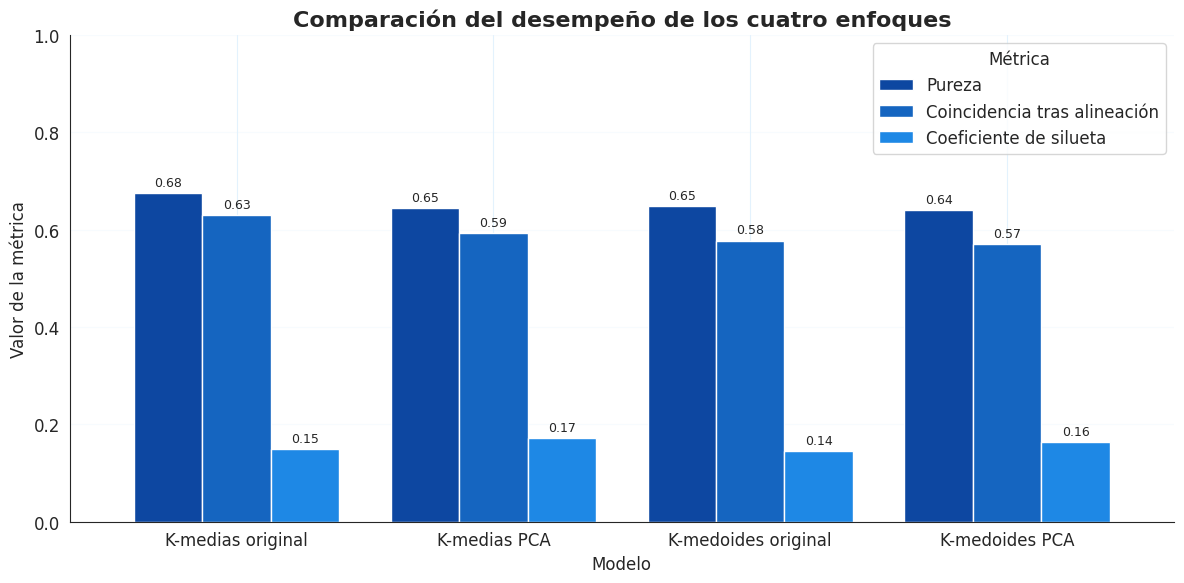

In [50]:
# Tabla comparativa de los 4 enfoques
comparacion_general = pd.DataFrame({
    "Métrica": ["Pureza", "Coincidencia tras alineación", "Coeficiente de silueta"],
    "K-medias original": [pureza_crudo, coincidencias, silueta],
    "K-medias PCA": [pureza_pca, coincidencias_pca, silueta_pca],
    "K-medoides original": [pureza_medoides_crudo, coincidencias_medoides_crudo, silueta_medoides_crudo],
    "K-medoides PCA": [pureza_medoides_pca, coincidencias_medoides_pca, silueta_medoides_pca]
})
mostrar_tabla(comparacion_general, "Comparación de los 4 algoritmos")

# Preparar los datos para la gráfica

comparacion_grafica = comparacion_general.set_index(
    "Métrica"
).T


# Crear la gráfica

ax = comparacion_grafica.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.8
)


plt.title(
    "Comparación del desempeño de los cuatro enfoques",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Modelo")
plt.ylabel("Valor de la métrica")

plt.xticks(
    rotation=0
)

plt.ylim(0, 1)


plt.legend(
    title="Métrica"
)

plt.grid(
    axis="y",
    alpha=0.25
)


# Mostrar el valor sobre cada barra

for contenedor in ax.containers:

    ax.bar_label(
        contenedor,
        fmt="%.2f",
        padding=3,
        fontsize=9
    )


plt.tight_layout()
plt.show()

El mejor desempeño para identificar a los empleados lo obtuvo K-medias sobre las imágenes originales, con la mayor pureza **(67.5 %)** y la mayor coincidencia tras alineación **(63%)**. La aplicación de PCA no mejoró la identificación de las personas: aunque K-medias + PCA alcanzó la mayor silueta (0,1726), redujo la pureza a **64.5%** y la coincidencia a **59.2%**. En conjunto, los resultados muestran que una mejor separación de los clusters no implica necesariamente una mejor correspondencia con las identidades reales.

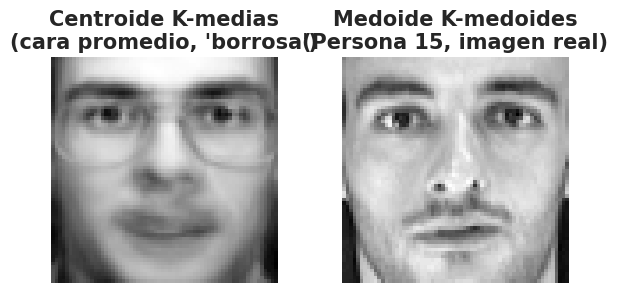

In [51]:
# Comparar centroide (K-medias) vs medoide (K-medoides) en el cluster problemático
cluster_ejemplo = 9

# Centroide de K-medias sobre PCA, reconstruido al espacio de píxeles
centroide_kmedias = kmeans_pca.cluster_centers_[cluster_ejemplo]
centroide_reconstruido = pca.inverse_transform(centroide_kmedias)

# Medoide de K-medoides sobre PCA (imagen real correspondiente)
indice_medoide = kmedoids_pca.medoid_indices_[cluster_ejemplo]
imagen_medoide = X_crudo[indice_medoide]

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(centroide_reconstruido.reshape(64, 64), cmap="gray")
axes[0].set_title("Centroide K-medias\n(cara promedio, 'borrosa')")
axes[0].axis("off")

axes[1].imshow(imagen_medoide.reshape(64, 64), cmap="gray")
axes[1].set_title(f"Medoide K-medoides\n(Persona {personas[indice_medoide]}, imagen real)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

La diferencia visual entre ambos métodos es clara: el centroide de K-medias representa una cara promedio y por eso pierde nitidez y detalles individuales, mientras que el medoide de K-medoides conserva los rasgos de una fotografía real. Sin embargo, esta mayor interpretabilidad visual del medoide no se reflejó en un mejor desempeño global, ya que K-medias sobre las imágenes originales obtuvo las mejores métricas de identificación.

## Paso 6. ¿Qué ocurre cuando no conocemos K?

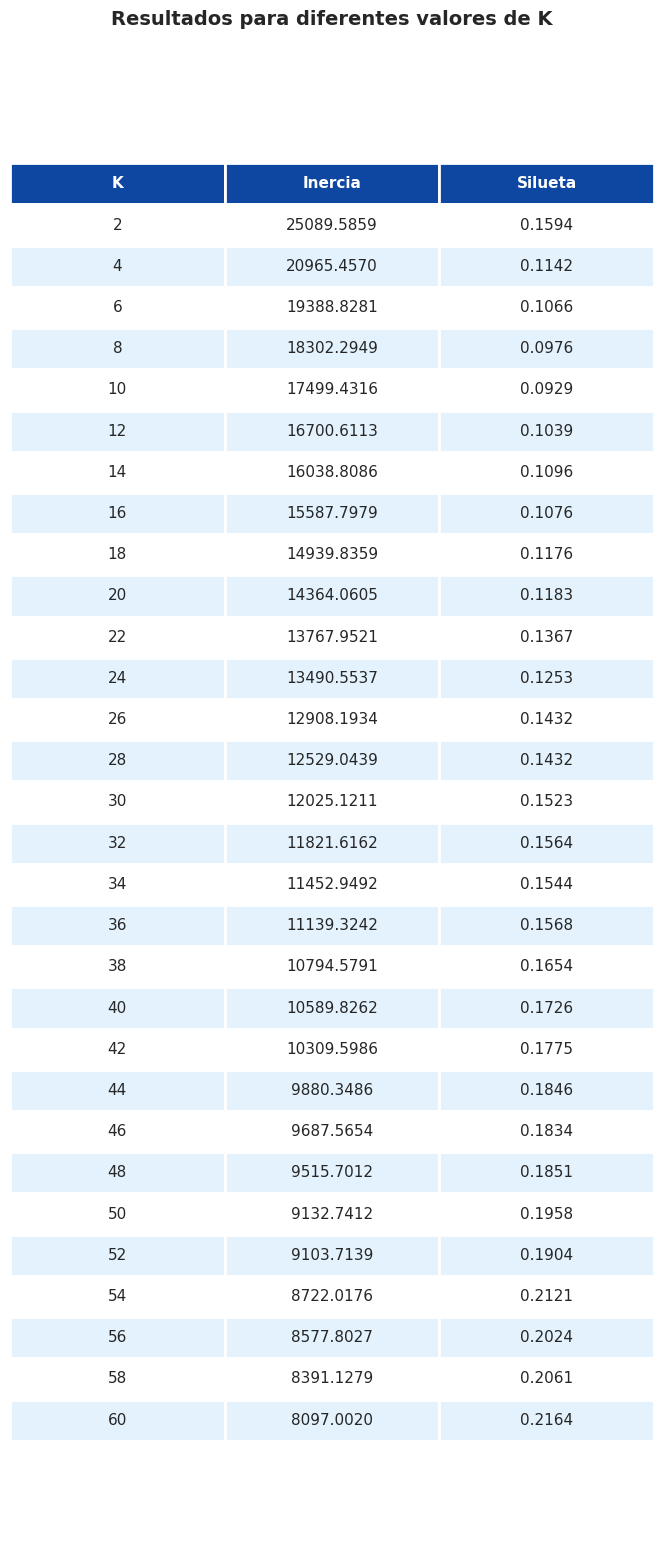

In [52]:
# Rango de valores de K a explorar
valores_k = list(range(2, 61, 2))

inercias = []
siluetas = []

for k in valores_k:
    kmeans_k = KMeans(
        n_clusters=k,
        random_state=123,
        n_init=10
    )
    clusters_k = kmeans_k.fit_predict(X_pca)

    inercias.append(kmeans_k.inertia_)
    siluetas.append(silhouette_score(X_pca, clusters_k))

resultados_k = pd.DataFrame({
    "K": valores_k,
    "Inercia": inercias,
    "Silueta": siluetas
})

mostrar_tabla(
    resultados_k,
    "Resultados para diferentes valores de K"
)

Al aumentar el número de clusters, la inercia disminuye de forma continua, mientras que la silueta no mejora de manera inmediata: inicialmente baja desde 0,1594 con K=2 hasta valores cercanos a 0,093, y posteriormente comienza a crecer. Esto muestra que los dos criterios no necesariamente conducen al mismo valor óptimo de K.

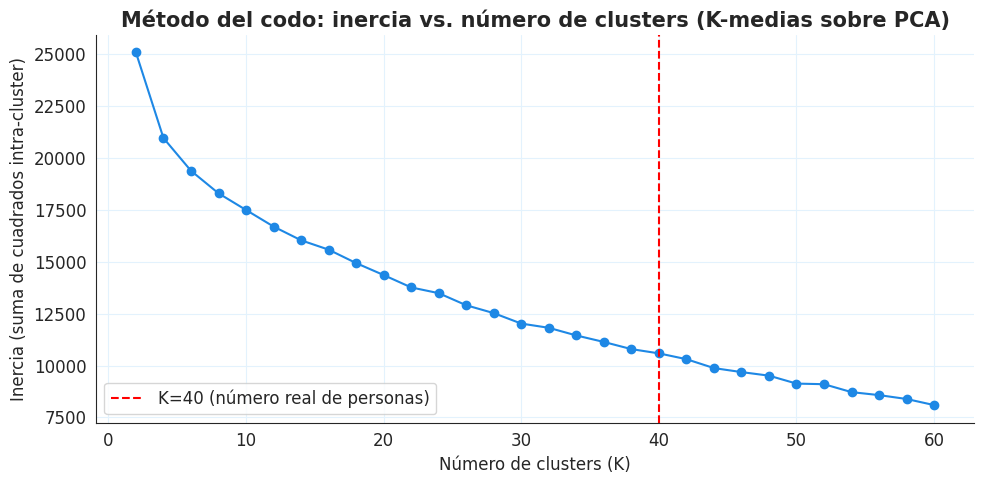

In [53]:
# Gráfica método del codo
plt.figure(figsize=(10, 5))
plt.plot(valores_k, inercias, marker="o", color=AZUL)
plt.axvline(x=40, color="red", linestyle="--", label="K=40 (número real de personas)")
plt.title("Método del codo: inercia vs. número de clusters (K-medias sobre PCA)")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inercia (suma de cuadrados intra-cluster)")
plt.legend()
plt.tight_layout()
plt.show()

La inercia disminuye rápidamente con valores bajos de K y después la curva se vuelve progresivamente más plana. Sin embargo, no se observa un codo claramente definido en K=40; la inercia sigue reduciéndose incluso después de este punto. Por tanto, utilizando únicamente este criterio, el número real de personas no podría identificarse con precisión.

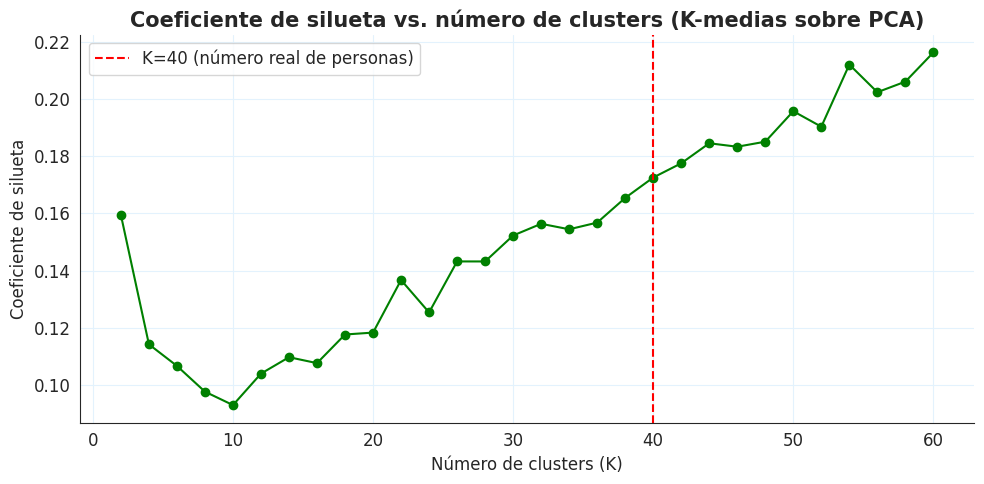

In [54]:
# Gráfica coeficiente de silueta
plt.figure(figsize=(10, 5))
plt.plot(valores_k, siluetas, marker="o", color="green")
plt.axvline(x=40, color="red", linestyle="--", label="K=40 (número real de personas)")
plt.title("Coeficiente de silueta vs. número de clusters (K-medias sobre PCA)")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Coeficiente de silueta")
plt.legend()
plt.tight_layout()
plt.show()

La silueta alcanza 0,1726 en K=40, superando los valores obtenidos con la mayoría de los K menores. Sin embargo, continúa aumentando después de K=40 y alcanza sus valores más altos con números de clusters mayores, llegando aproximadamente a 0,217 con K=60. Esto indica que la silueta favorece una mayor fragmentación de los datos y tampoco permite recuperar por sí sola el número real de identidades.

## Paso 7. Integración de resultados y recomendación

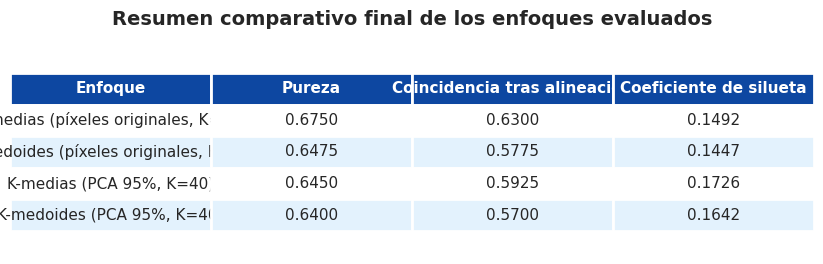

In [55]:
# Tabla resumen final de todos los enfoques evaluados
resumen_final = pd.DataFrame({
    "Enfoque": [
        "K-medias (píxeles originales, K=40)",
        "K-medias (PCA 95%, K=40)",
        "K-medoides (píxeles originales, K=40)",
        "K-medoides (PCA 95%, K=40)"
    ],
    "Pureza": [pureza_crudo, pureza_pca, pureza_medoides_crudo, pureza_medoides_pca],
    "Coincidencia tras alineación": [coincidencias, coincidencias_pca, coincidencias_medoides_crudo, coincidencias_medoides_pca],
    "Coeficiente de silueta": [silueta, silueta_pca, silueta_medoides_crudo, silueta_medoides_pca]
})

resumen_final = resumen_final.sort_values("Pureza", ascending=False).reset_index(drop=True)
mostrar_tabla(resumen_final, "Resumen comparativo final de los enfoques evaluados")

Al integrar las métricas de los algoritmos desarrollados, K-medias sobre píxeles originales presenta el mejor resultado para relacionar los clusters con las identidades reales, con una pureza de **67.5%** y una coincidencia alineada de **63%**. En contraste, K-medias + PCA obtiene la mayor silueta (0,1726), mientras que K-medoides + PCA conserva resultados similares de separación (0,1642) pero con menor capacidad para recuperar correctamente las identidades. Por tanto, cada métrica favorece un aspecto diferente del agrupamiento.

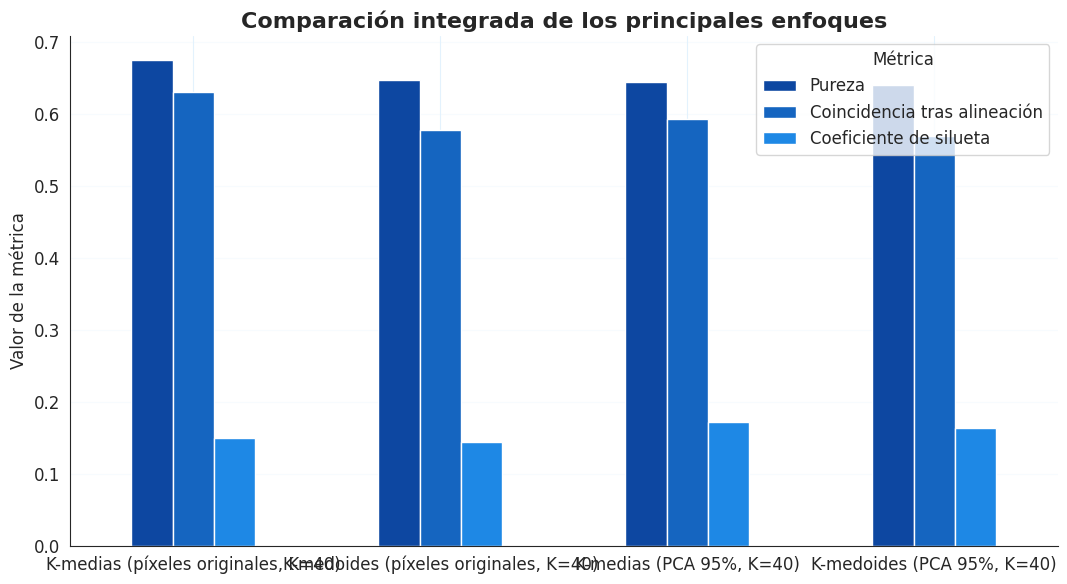

In [56]:
datos_grafica = resumen_final.set_index("Enfoque")

ax = datos_grafica.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title(
    "Comparación integrada de los principales enfoques",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("Valor de la métrica")

plt.xticks(rotation=0)

plt.legend(title="Métrica")

plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

La comparación visual confirma que no existe un único enfoque dominante en todas las métricas. K-medias sobre píxeles originales lidera la pureza y la coincidencia con las identidades reales, mientras que K-medias + PCA presenta una mejor separación interna según la silueta. Esto demuestra que seleccionar el modelo únicamente por la silueta habría llevado a una conclusión diferente de la obtenida al considerar las identificaciones reales.

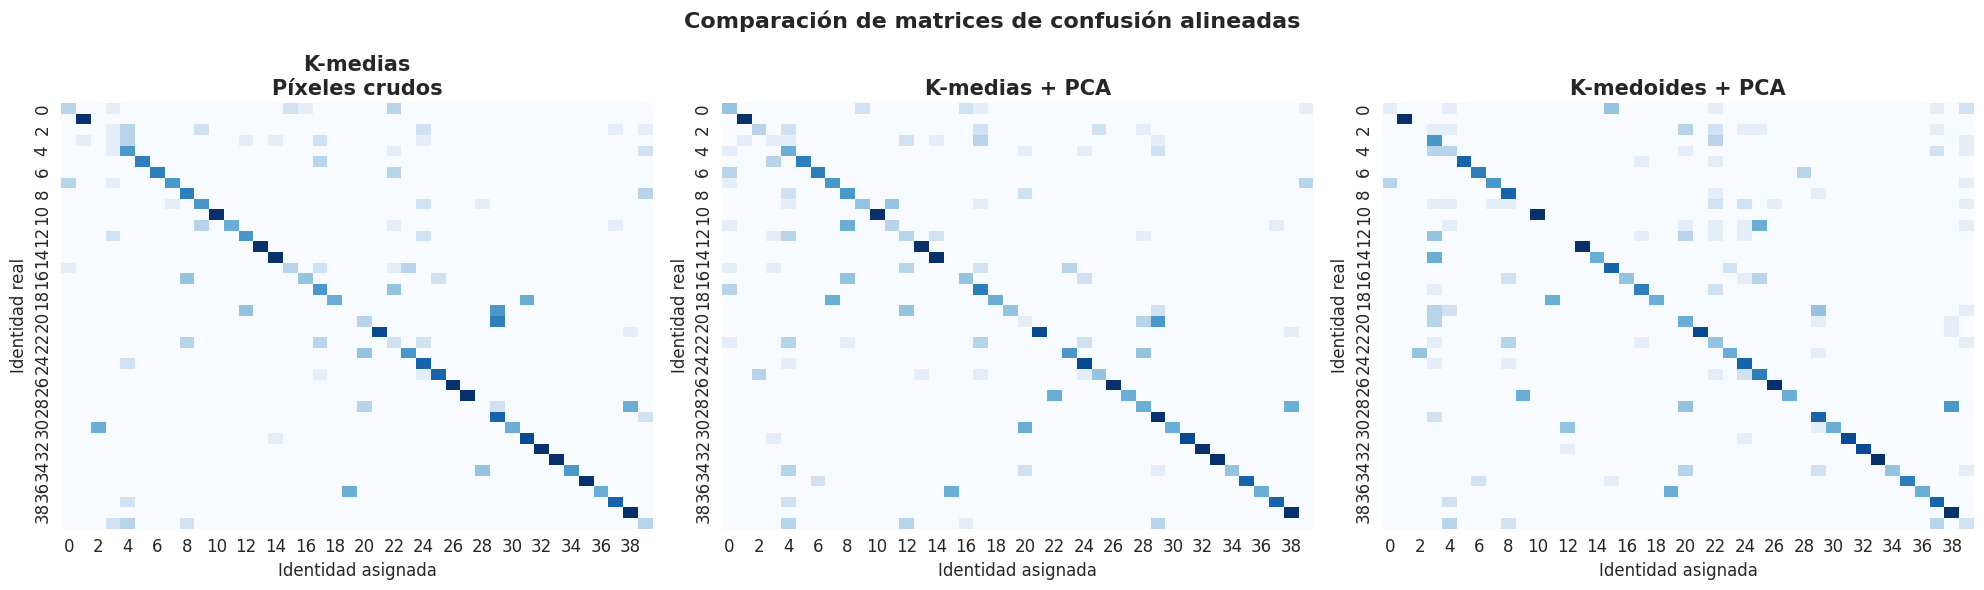

In [57]:
# Matriz alineada para K-medoides sobre PCA
matriz_alineada_mp = confusion_matrix(
    personas,
    clusters_alineados_mp
)

# Comparación visual de las matrices alineadas

fig, axes = plt.subplots(
    1, 3,
    figsize=(20, 6)
)

# K-medias sobre píxeles crudos
sns.heatmap(
    matriz_alineada,
    cmap="Blues",
    cbar=False,
    ax=axes[0]
)

axes[0].set_title(
    "K-medias\nPíxeles crudos",
    fontweight="bold"
)
axes[0].set_xlabel("Identidad asignada")
axes[0].set_ylabel("Identidad real")


# K-medias sobre PCA
sns.heatmap(
    matriz_alineada_pca,
    cmap="Blues",
    cbar=False,
    ax=axes[1]
)

axes[1].set_title(
    "K-medias + PCA",
    fontweight="bold"
)
axes[1].set_xlabel("Identidad asignada")
axes[1].set_ylabel("Identidad real")


# K-medoides sobre PCA
sns.heatmap(
    matriz_alineada_mp,
    cmap="Blues",
    cbar=False,
    ax=axes[2]
)

axes[2].set_title(
    "K-medoides + PCA",
    fontweight="bold"
)
axes[2].set_xlabel("Identidad asignada")
axes[2].set_ylabel("Identidad real")


plt.suptitle(
    "Comparación de matrices de confusión alineadas",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

Las matrices alineadas complementan los resultados de pureza y silueta al mostrar dónde se concentran los aciertos y las confusiones entre personas. K-medias sobre píxeles crudos presenta la mayor coincidencia tras la alineación **(63,%)**, seguido por K-medias + PCA **(59.2%)** y K-medoides + PCA **(57%)**. Visualmente, ningún enfoque concentra completamente los valores en la diagonal, lo que confirma que algunas identidades continúan mezclándose entre clusters.

**Recomendación final**

De acuerdo con los resultados obtenidos, consideramos que el clustering sí puede servir como una herramienta de apoyo para organizar y reconciliar las fotografías, pero no sería recomendable utilizarlo de manera completamente automática para asignar las identidades.

De las alternativas que evaluamos, K-medias utilizando los píxeles originales y K=40 fue la configuración que mostró mejores resultados, con una pureza de 67,5% y una coincidencia después de alinear los clusters de 63%. Aun así, estos valores muestran que todavía existen varias fotografías de diferentes personas que terminan mezclándose dentro de los mismos grupos. Esto es importante porque la base Olivetti se encuentra relativamente controlada y balanceada, mientras que en las fotografías reales de la empresa probablemente existirán mayores diferencias de iluminación, posición, fecha de captura y apariencia.

También evaluamos la reducción de dimensionalidad mediante PCA. Con este procedimiento se logró pasar de 4.096 píxeles a 123 componentes, manteniendo aproximadamente el 95% de la varianza. Sin embargo, en nuestro caso esta reducción no produjo una mejora en la capacidad del clustering para separar correctamente las identidades. Por otro lado, K-medoides tiene ventajas como utilizar una fotografía real como representante de cada grupo y ser menos sensible a valores atípicos, pero tampoco obtuvo mejores resultados que K-medias.

Por lo anterior, nuestra recomendación sería utilizar el clustering principalmente como un filtro inicial. Es decir, el algoritmo podría formar grupos de fotografías que parecen corresponder a una misma persona y posteriormente un analista podría revisar y confirmar esos grupos. De esta forma se reduciría considerablemente el trabajo manual sin depender completamente de las decisiones del algoritmo.

Antes de utilizarlo sobre las cerca de 10.000 fotografías de la empresa, sería conveniente realizar primero un piloto con una muestra de fotografías reales. En esta prueba deberían incluirse diferentes condiciones de iluminación, poses y fechas, para comprobar qué tan bien se mantienen los resultados fuera de la base Olivetti. También sería importante definir algún criterio de pureza o confianza para decidir cuáles grupos pueden revisarse rápidamente y cuáles necesitan una validación manual más detallada.

Finalmente, encontramos una limitación adicional al analizar diferentes valores de K. Ni el método del codo ni el coeficiente de silueta permitieron identificar claramente las 40 personas reales presentes en la base. Esto sería especialmente importante al llevar el método a producción, ya que en el archivo real probablemente no se conocerá de antemano cuántas personas diferentes existen.

En conclusión, recomendamos avanzar con un piloto de clustering asistido por revisión humana, pero no utilizarlo todavía como un mecanismo automático para reasignar las identidades de todas las fotografías.